In [1]:
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import numpy as np

from tqdm import tqdm

import pandas as pd
from pprint import pprint

import seaborn as sns

from matplotlib import rcParams

rcParams["axes.facecolor"] = "FFFFFF"
rcParams["savefig.facecolor"] = "FFFFFF"
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"

rcParams.update({"figure.autolayout": True})

plt.rcParams["figure.figsize"] = (9,9)

import os
os.environ["OMP_NUM_THREADS"] = "8"         # Specify the number of threads
os.environ["OMP_DYNAMIC"] = "FALSE"        # Disable dynamic adjustment of threads
os.environ["OMP_PROC_BIND"] = "TRUE"        # Enable thread affinity
os.environ["OMP_PLACES"] = "cores"          # Define where threads are placed

import jax
import jax.numpy as jnp
import jax.random as random
from scipy.stats import nbinom
from jax.example_libraries import optimizers

from fast_negative_binomial import log_negative_binomial2, log_negative_binomial2_jac, optimise
from fast_mutual_information import mi_negative_binomial

ModuleNotFoundError: No module named 'jax'

In [2]:
def nb_mean(true_r, true_p):
    return true_r * ( 1 - true_p) / true_p
def nb_var(true_r, true_p):
    return nb_mean(true_r, true_p) / true_p

In [20]:
key = random.PRNGKey(0)
true_m, true_r = 10.0, 3.0
true_p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, true_p, size=(1000, 1234)).astype(np.int32)

<Axes: ylabel='Count'>

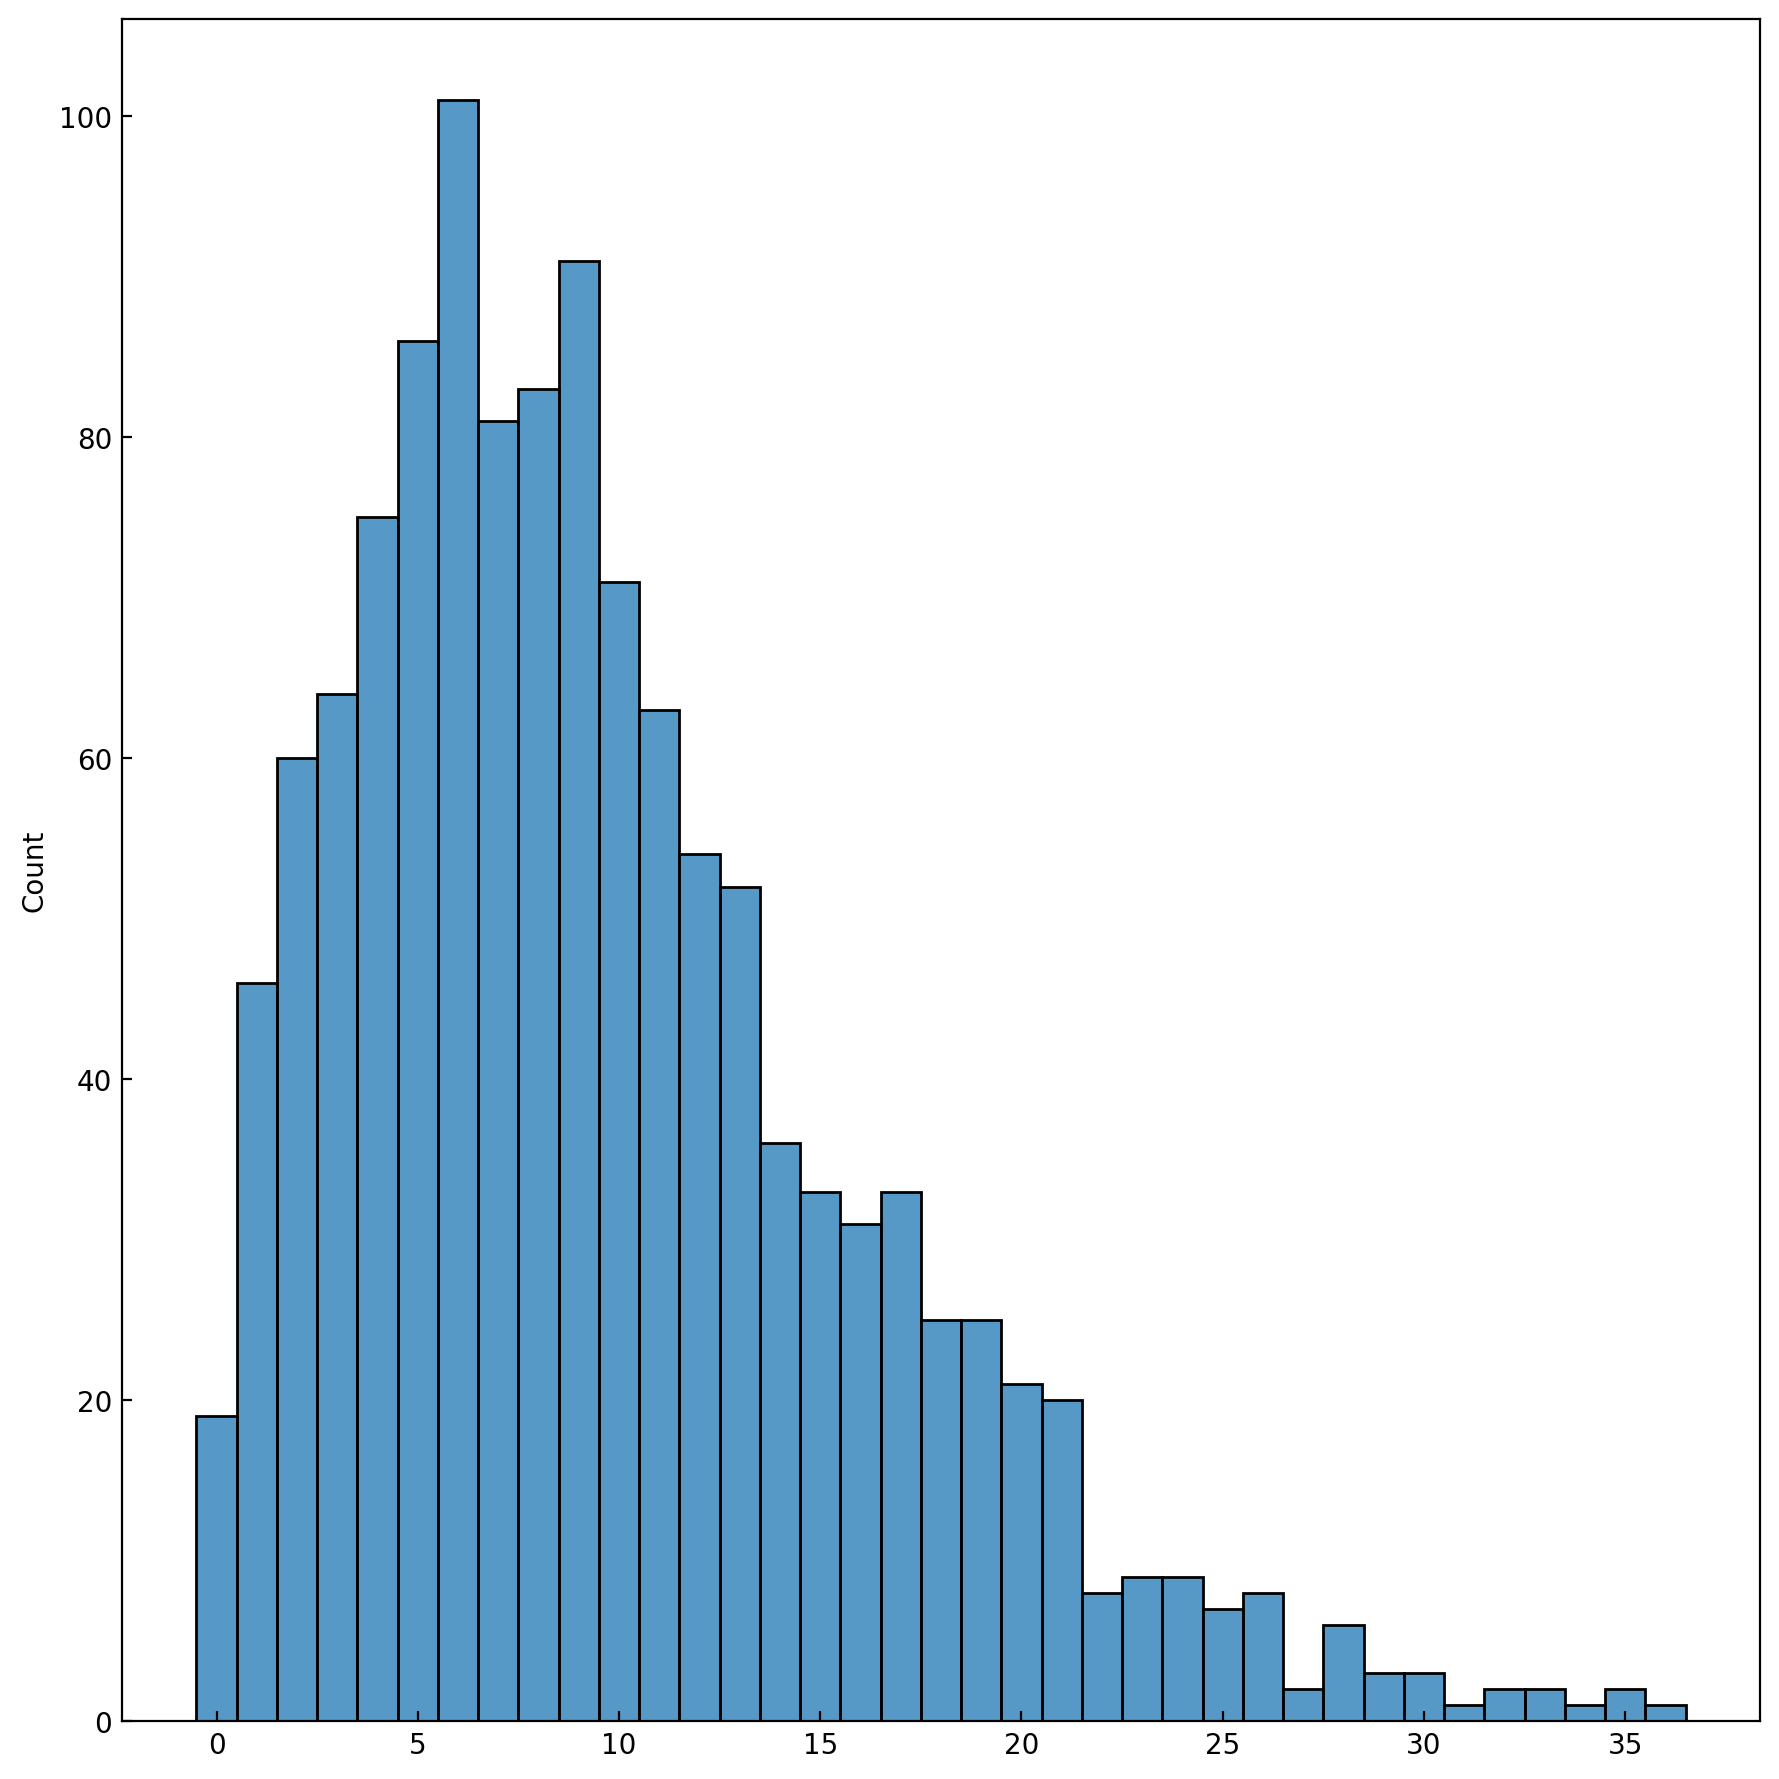

In [21]:
sns.histplot(data[0], bins=30, discrete=True)

In [22]:
means = np.array([true_m for i in range(len(data))])
variances = np.array([nb_var(true_r, true_p) for i in range(len(data))])
mi = mi_negative_binomial(data.T, means, variances)

inf -5.421013448269753e-06


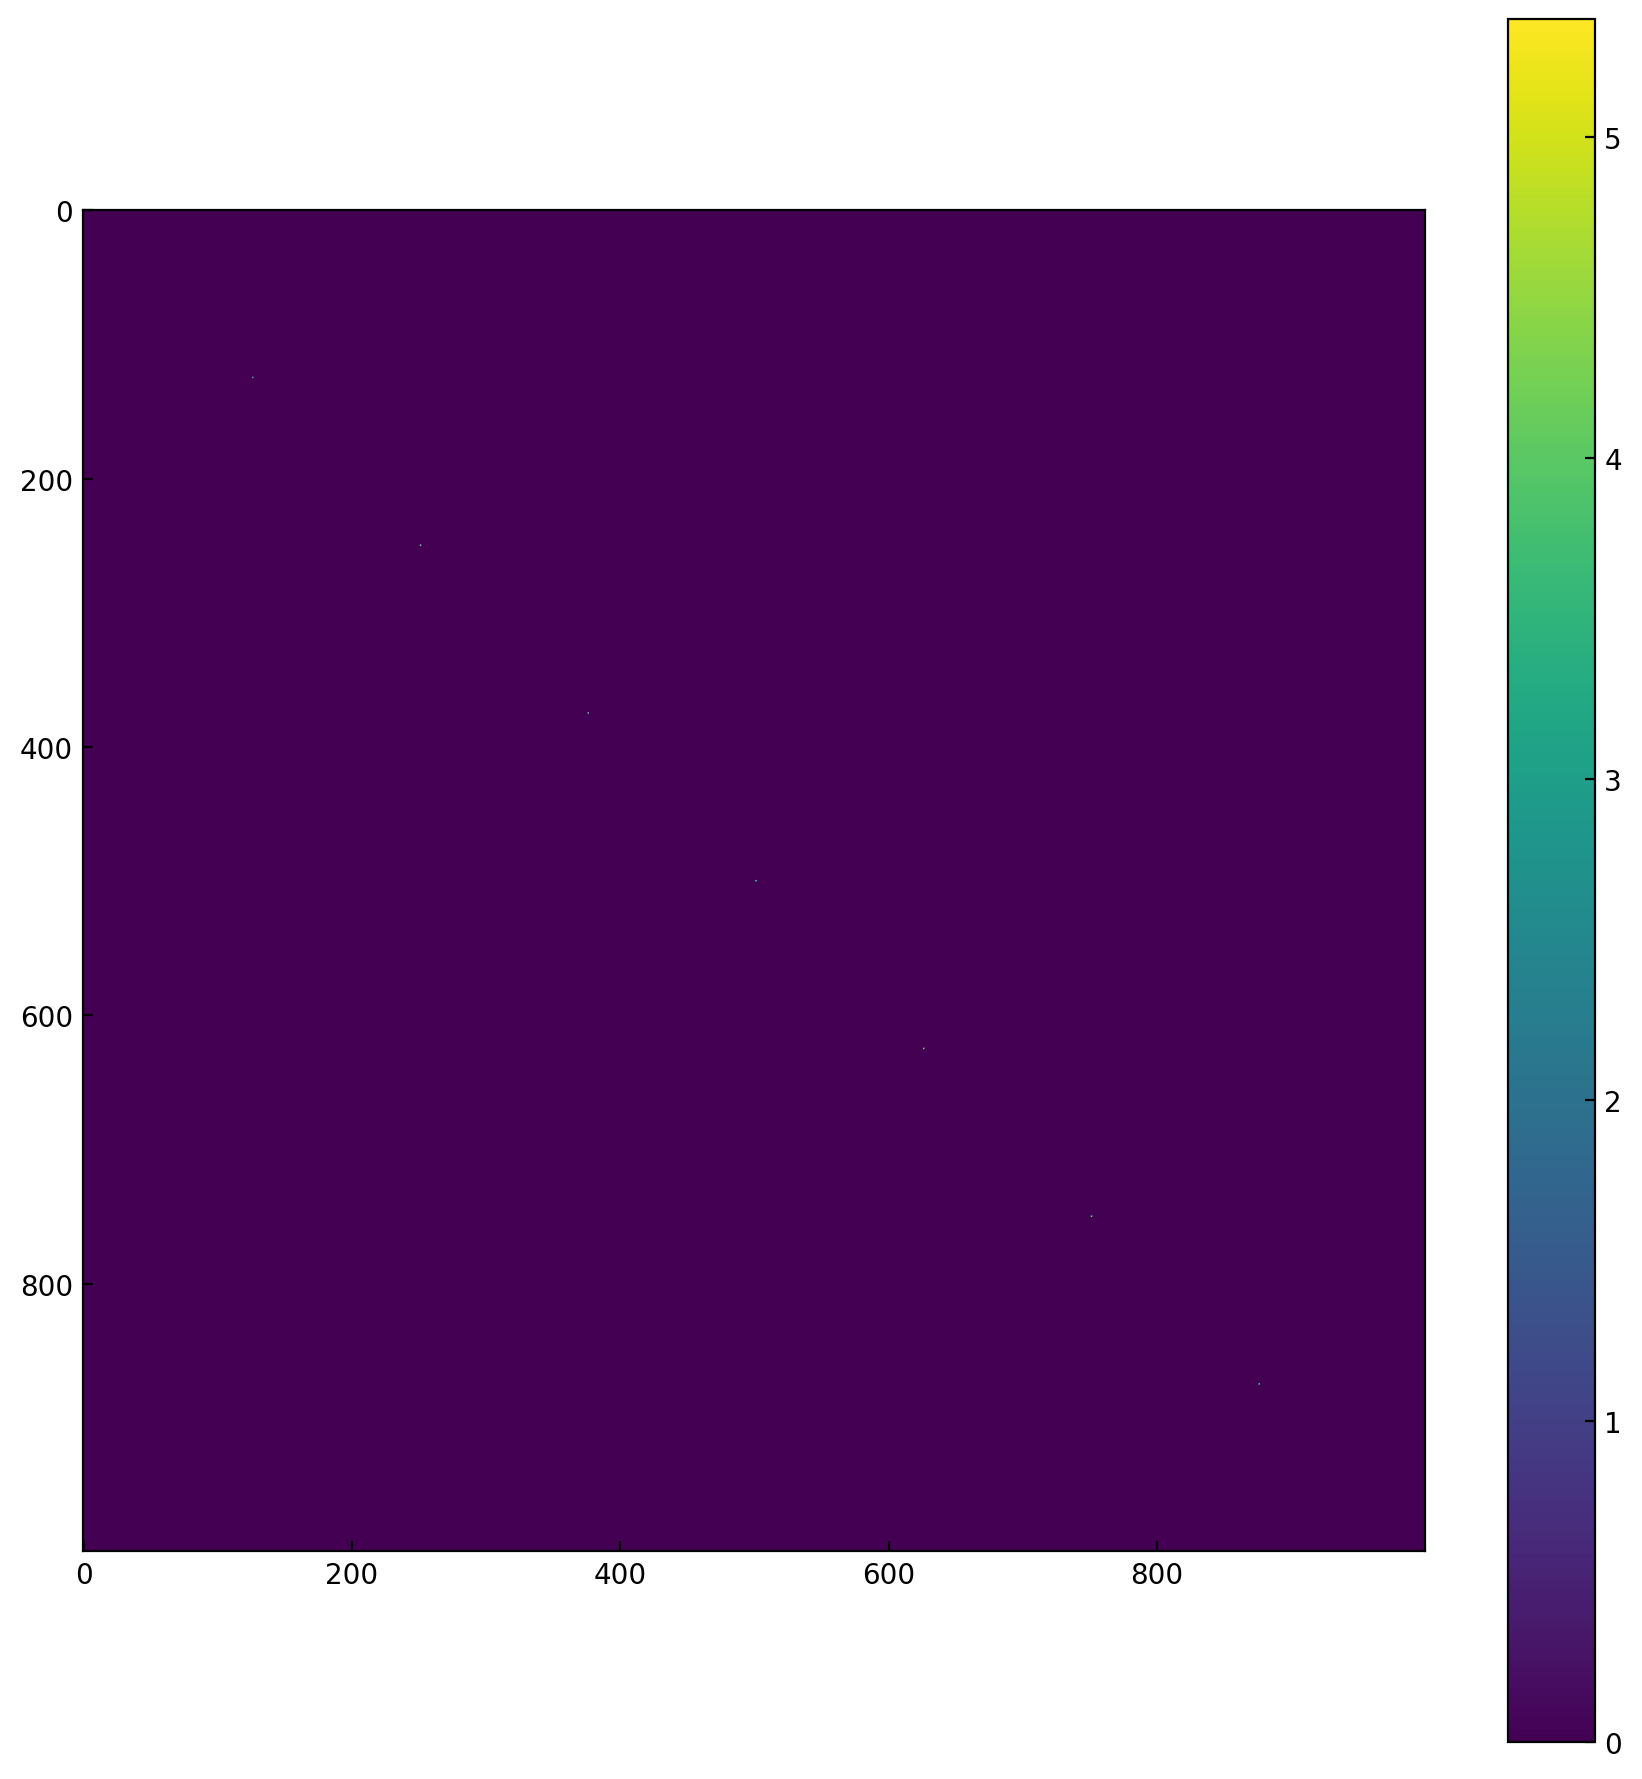

In [23]:
# sns.heatmap(mi)
plt.imshow(mi)
plt.colorbar()

print(np.max(mi), np.min(mi))

In [8]:
nb_grad = jax.jacrev(jax.scipy.stats.nbinom.logpmf, argnums=[1, 2])

# Assume your custom functions negative_binomial2 and negative_binomial2_jac are defined.
# They take arguments (k, m, r) and return, respectively, the log‐pmf and its jacobian (shape: (len(k), 2)).

# Sample 1000 data points from a negative binomial.
key = random.PRNGKey(0)
true_m, true_r = 10.0, 5.0
true_p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, true_p, size=1000).astype(np.int32)

def loss(params, k):
    r, m = params
    p = r / (r + m)
    likelihood = log_negative_binomial2(k, m, r)
    # print(nb_mean(r, p), nb_var(r, p), -np.sum(np.log(likelihood)), -jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p)))
    return -np.sum(likelihood)
    # return -jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p))
    # return np.sum(likelihood) - jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p))

def loss_grad(params, k):
    r, m = params
    jac = log_negative_binomial2_jac(k, m, r)
    # p = r / (r + m)
    # jac = jnp.vstack(nb_grad(k, r, p)).T
    return -jnp.mean(jac, axis=0)
    # return -jnp.sum(jac, axis = 0)

# Set up the Adam optimizer.
opt_init, opt_update, get_params = optimizers.adam(step_size=1e-2)

# @jax.jit
def step(i, opt_state, k):
    params = get_params(opt_state)
    grads = loss_grad(params, k)
    return opt_update(i, grads, opt_state)

# Initialize parameters (starting guess for m and r).
params0 = jnp.array([10.0, 10.0])
opt_state = opt_init(params0)

# for j in tqdm(range(1000)):

losses = []
ms = []
rs = []

    # Run the optimization for 1000 iterations.
    # for i in tqdm(range(1000)):
for i in tqdm(range(2000)):
    opt_state = step(i, opt_state, data)
    params = get_params(opt_state)
    losses.append(loss(params, data))
    ms.append(params[1])
    rs.append(params[0])

fitted_params = get_params(opt_state)
print("Fitted m: {:.3f}, r: {:.3f}".format(fitted_params[0], fitted_params[1]))


  2%|▏         | 46/2000 [00:00<00:20, 97.20it/s] 


KeyboardInterrupt: 

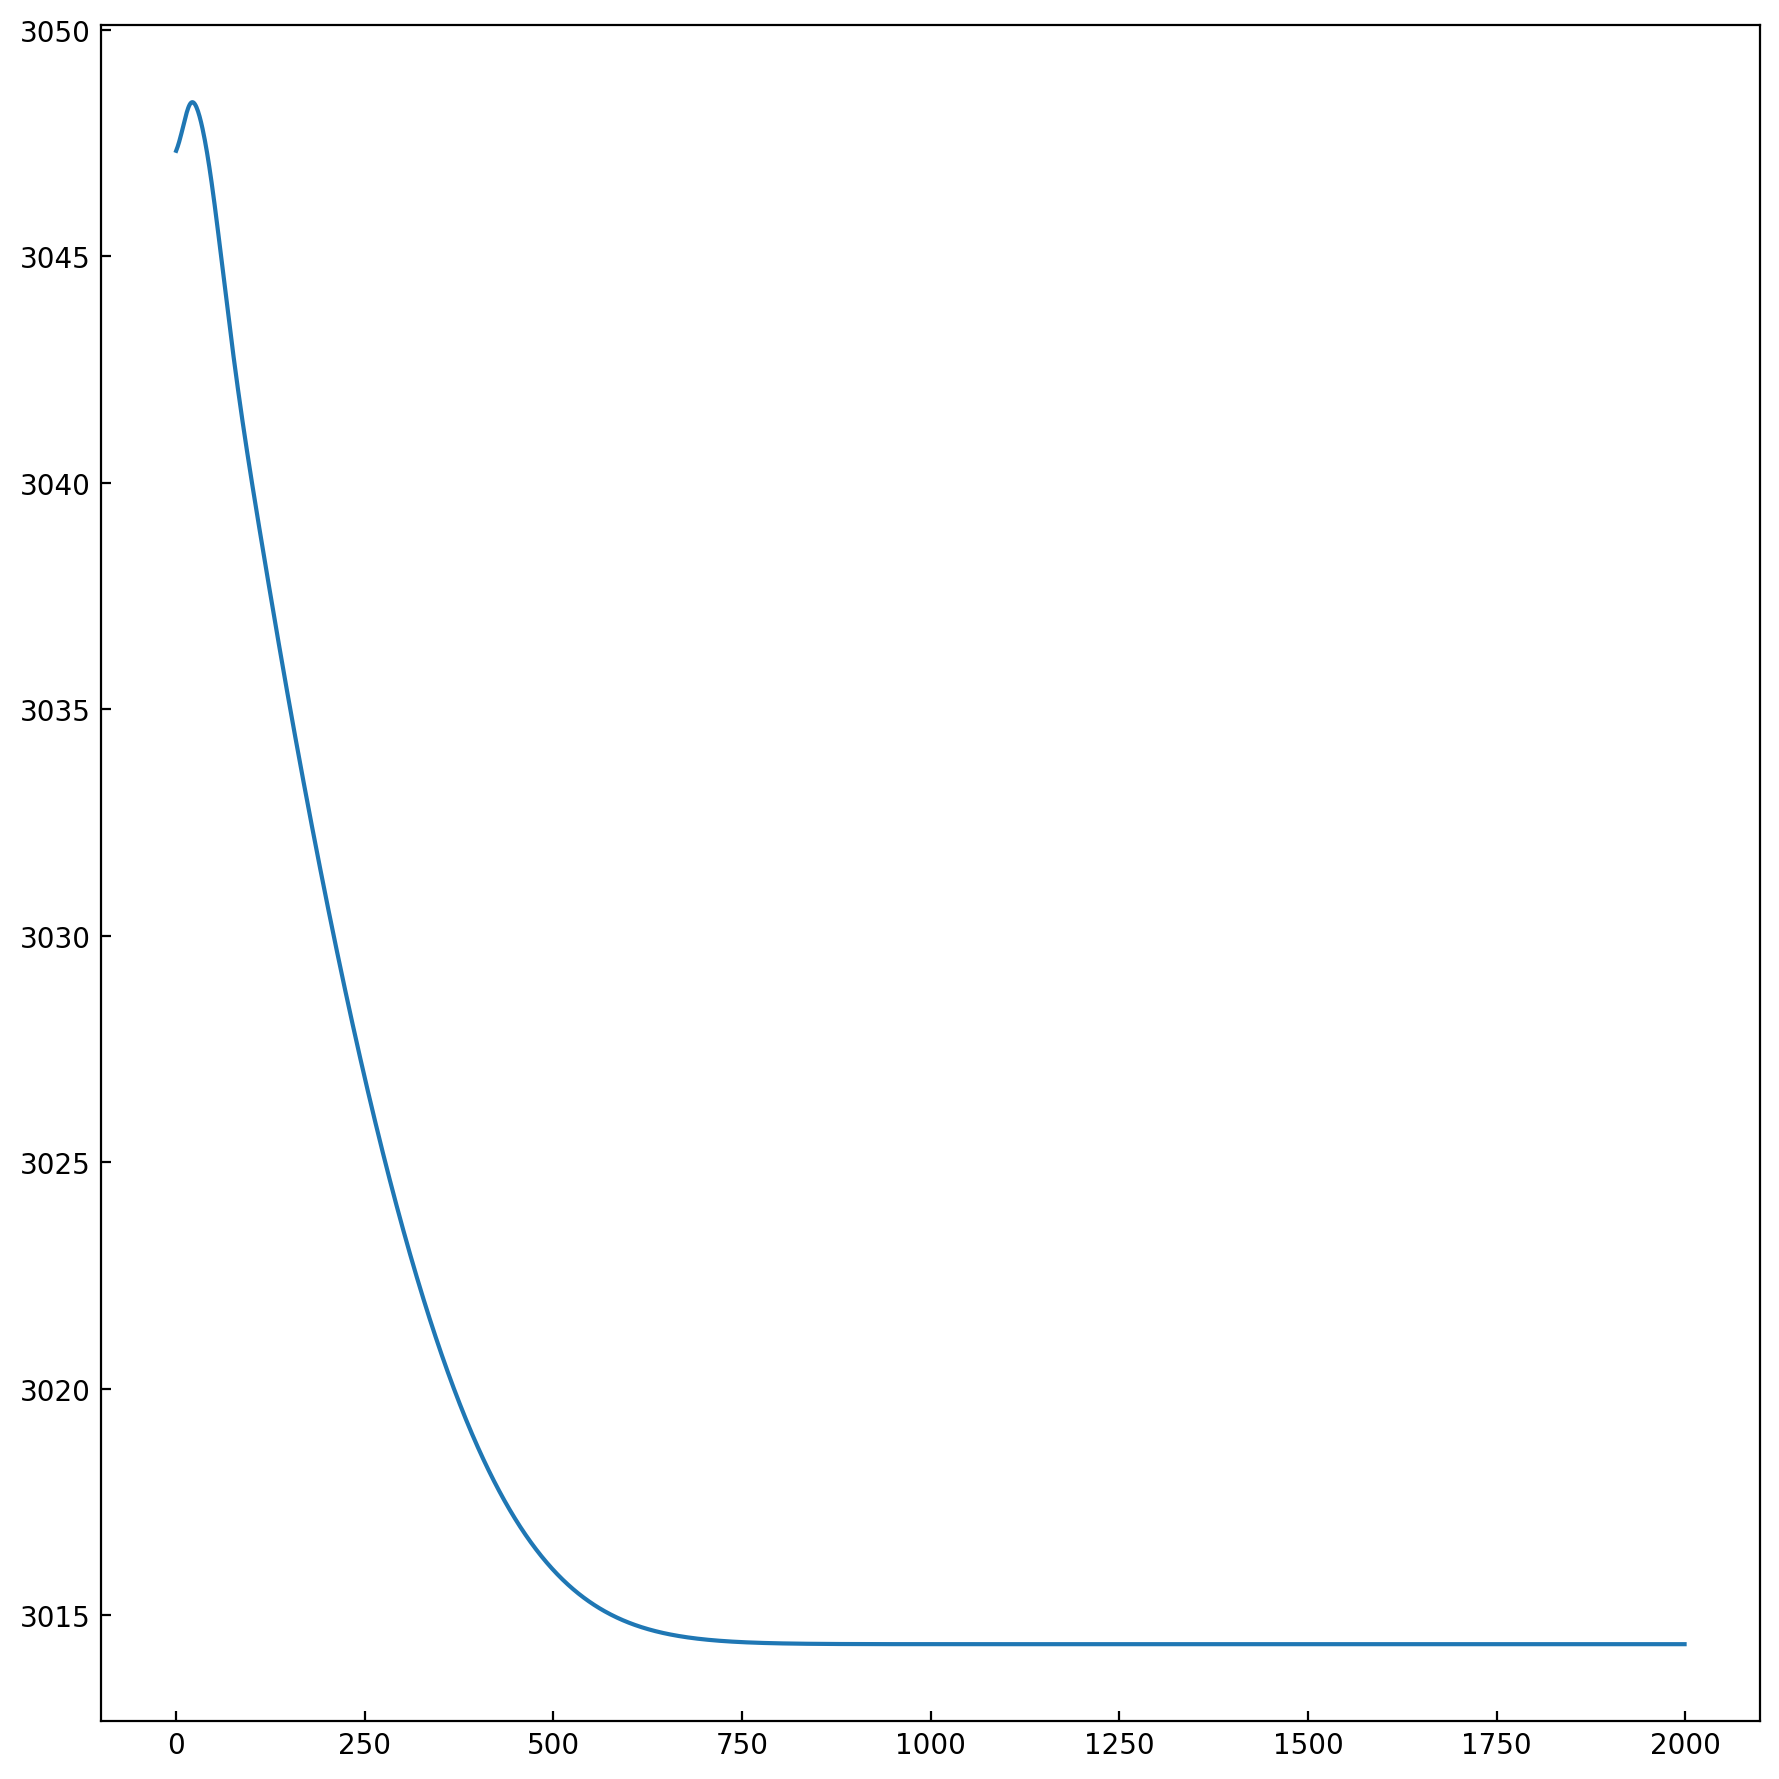

In [13]:
plt.plot(losses)

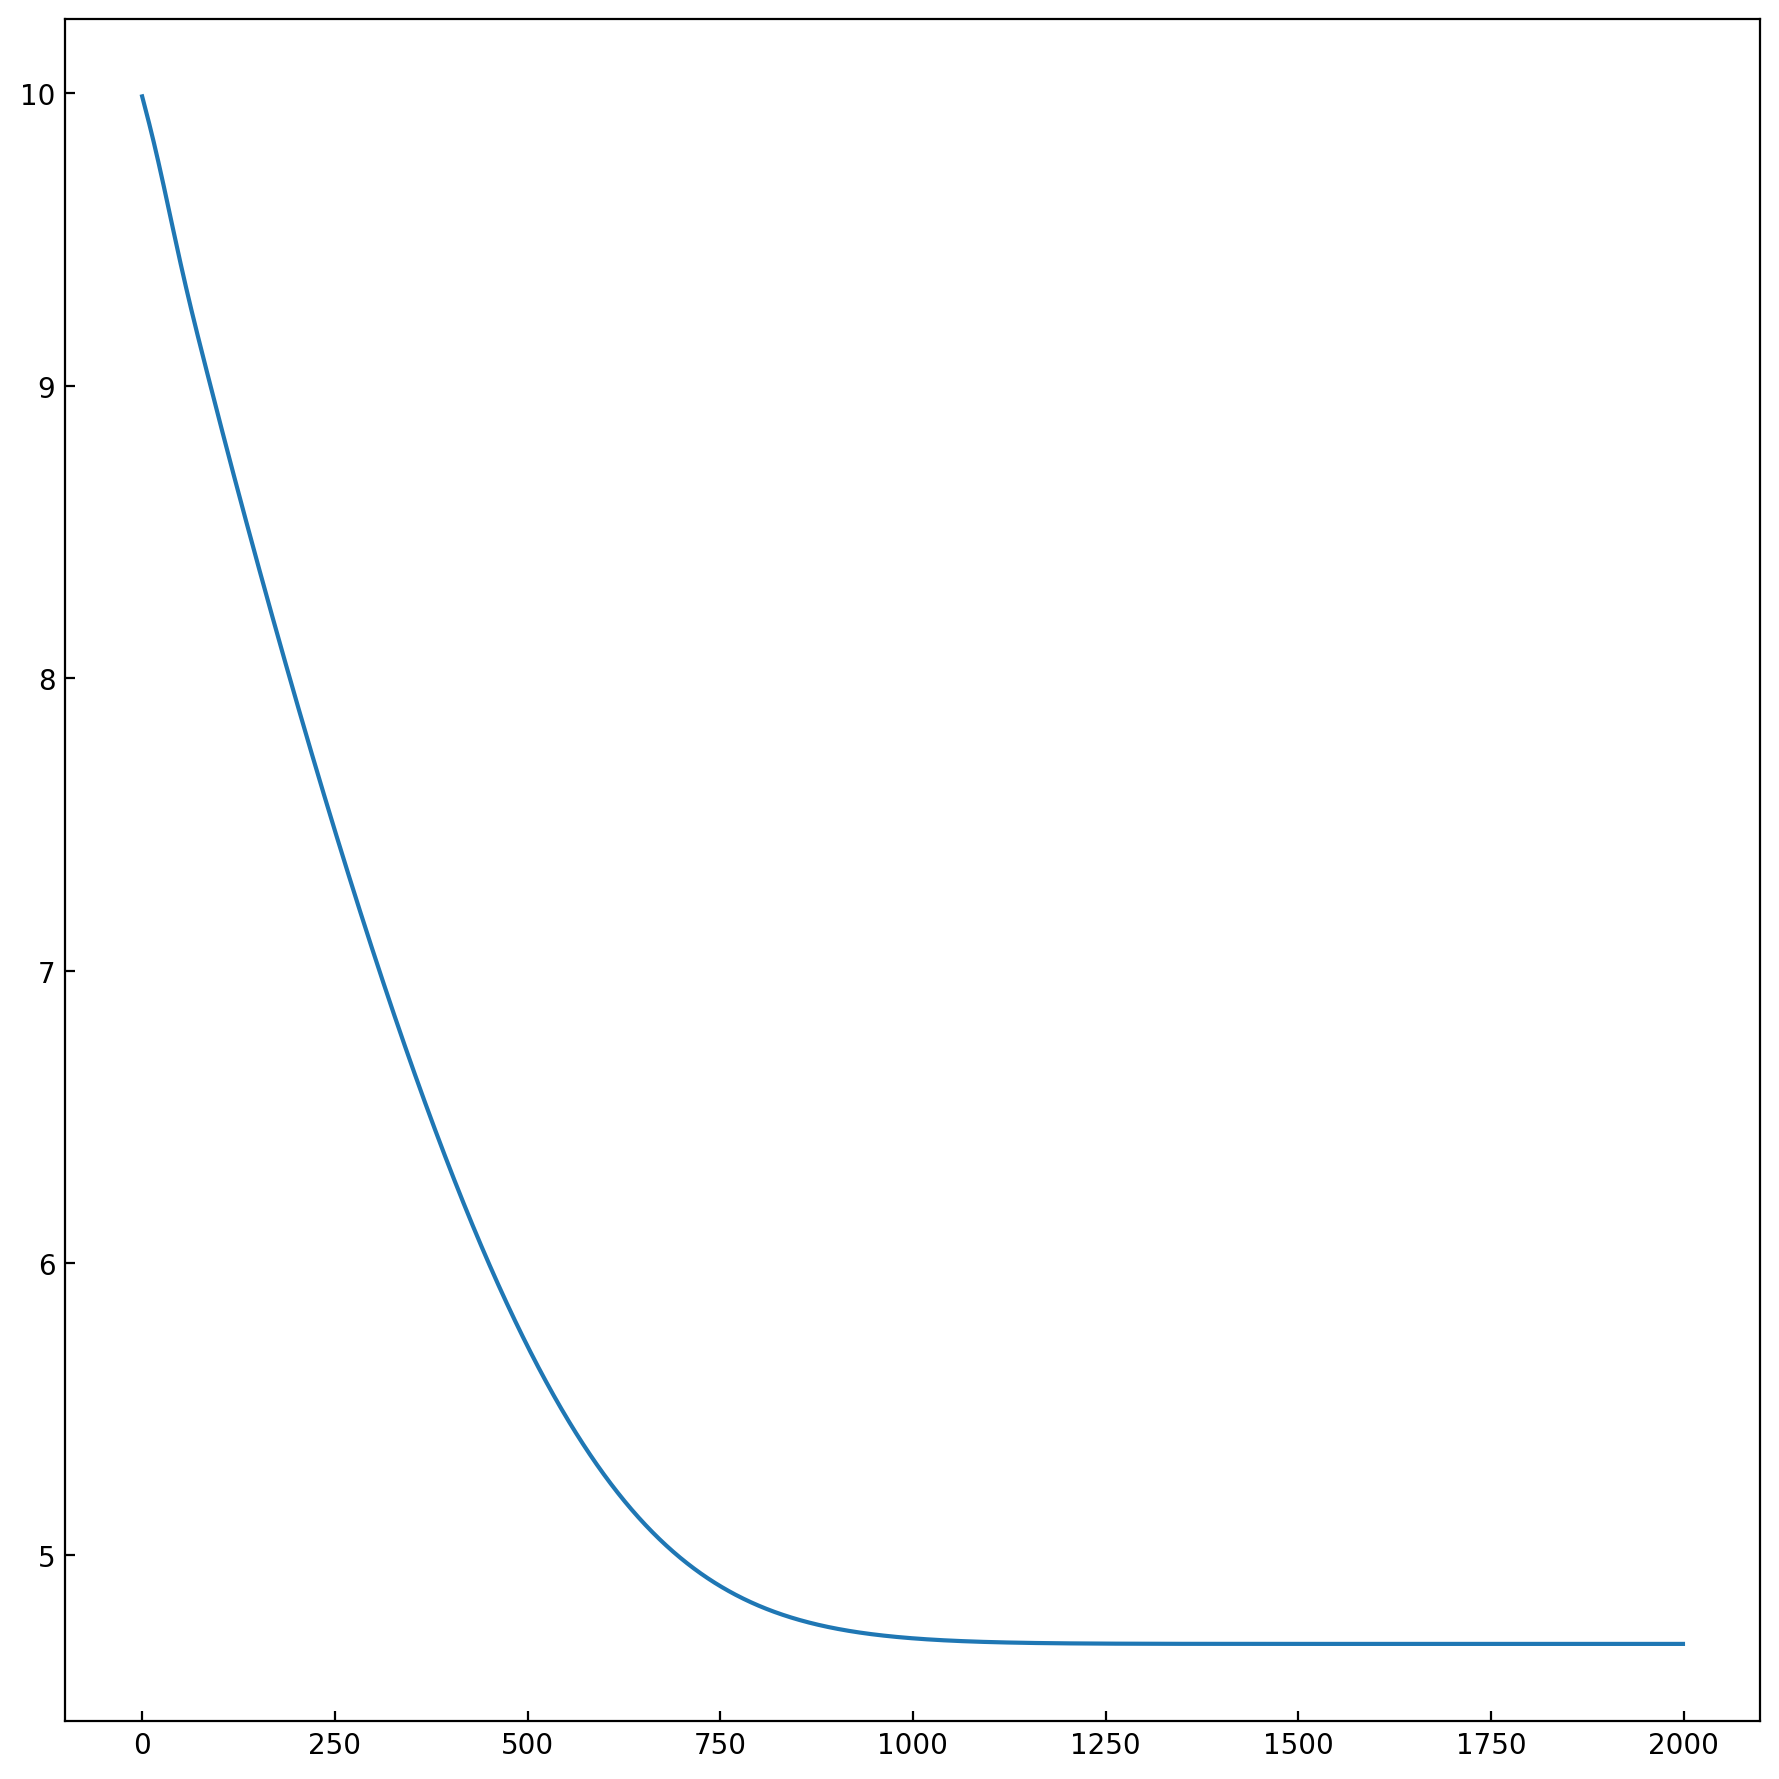

In [5]:
plt.plot(rs)

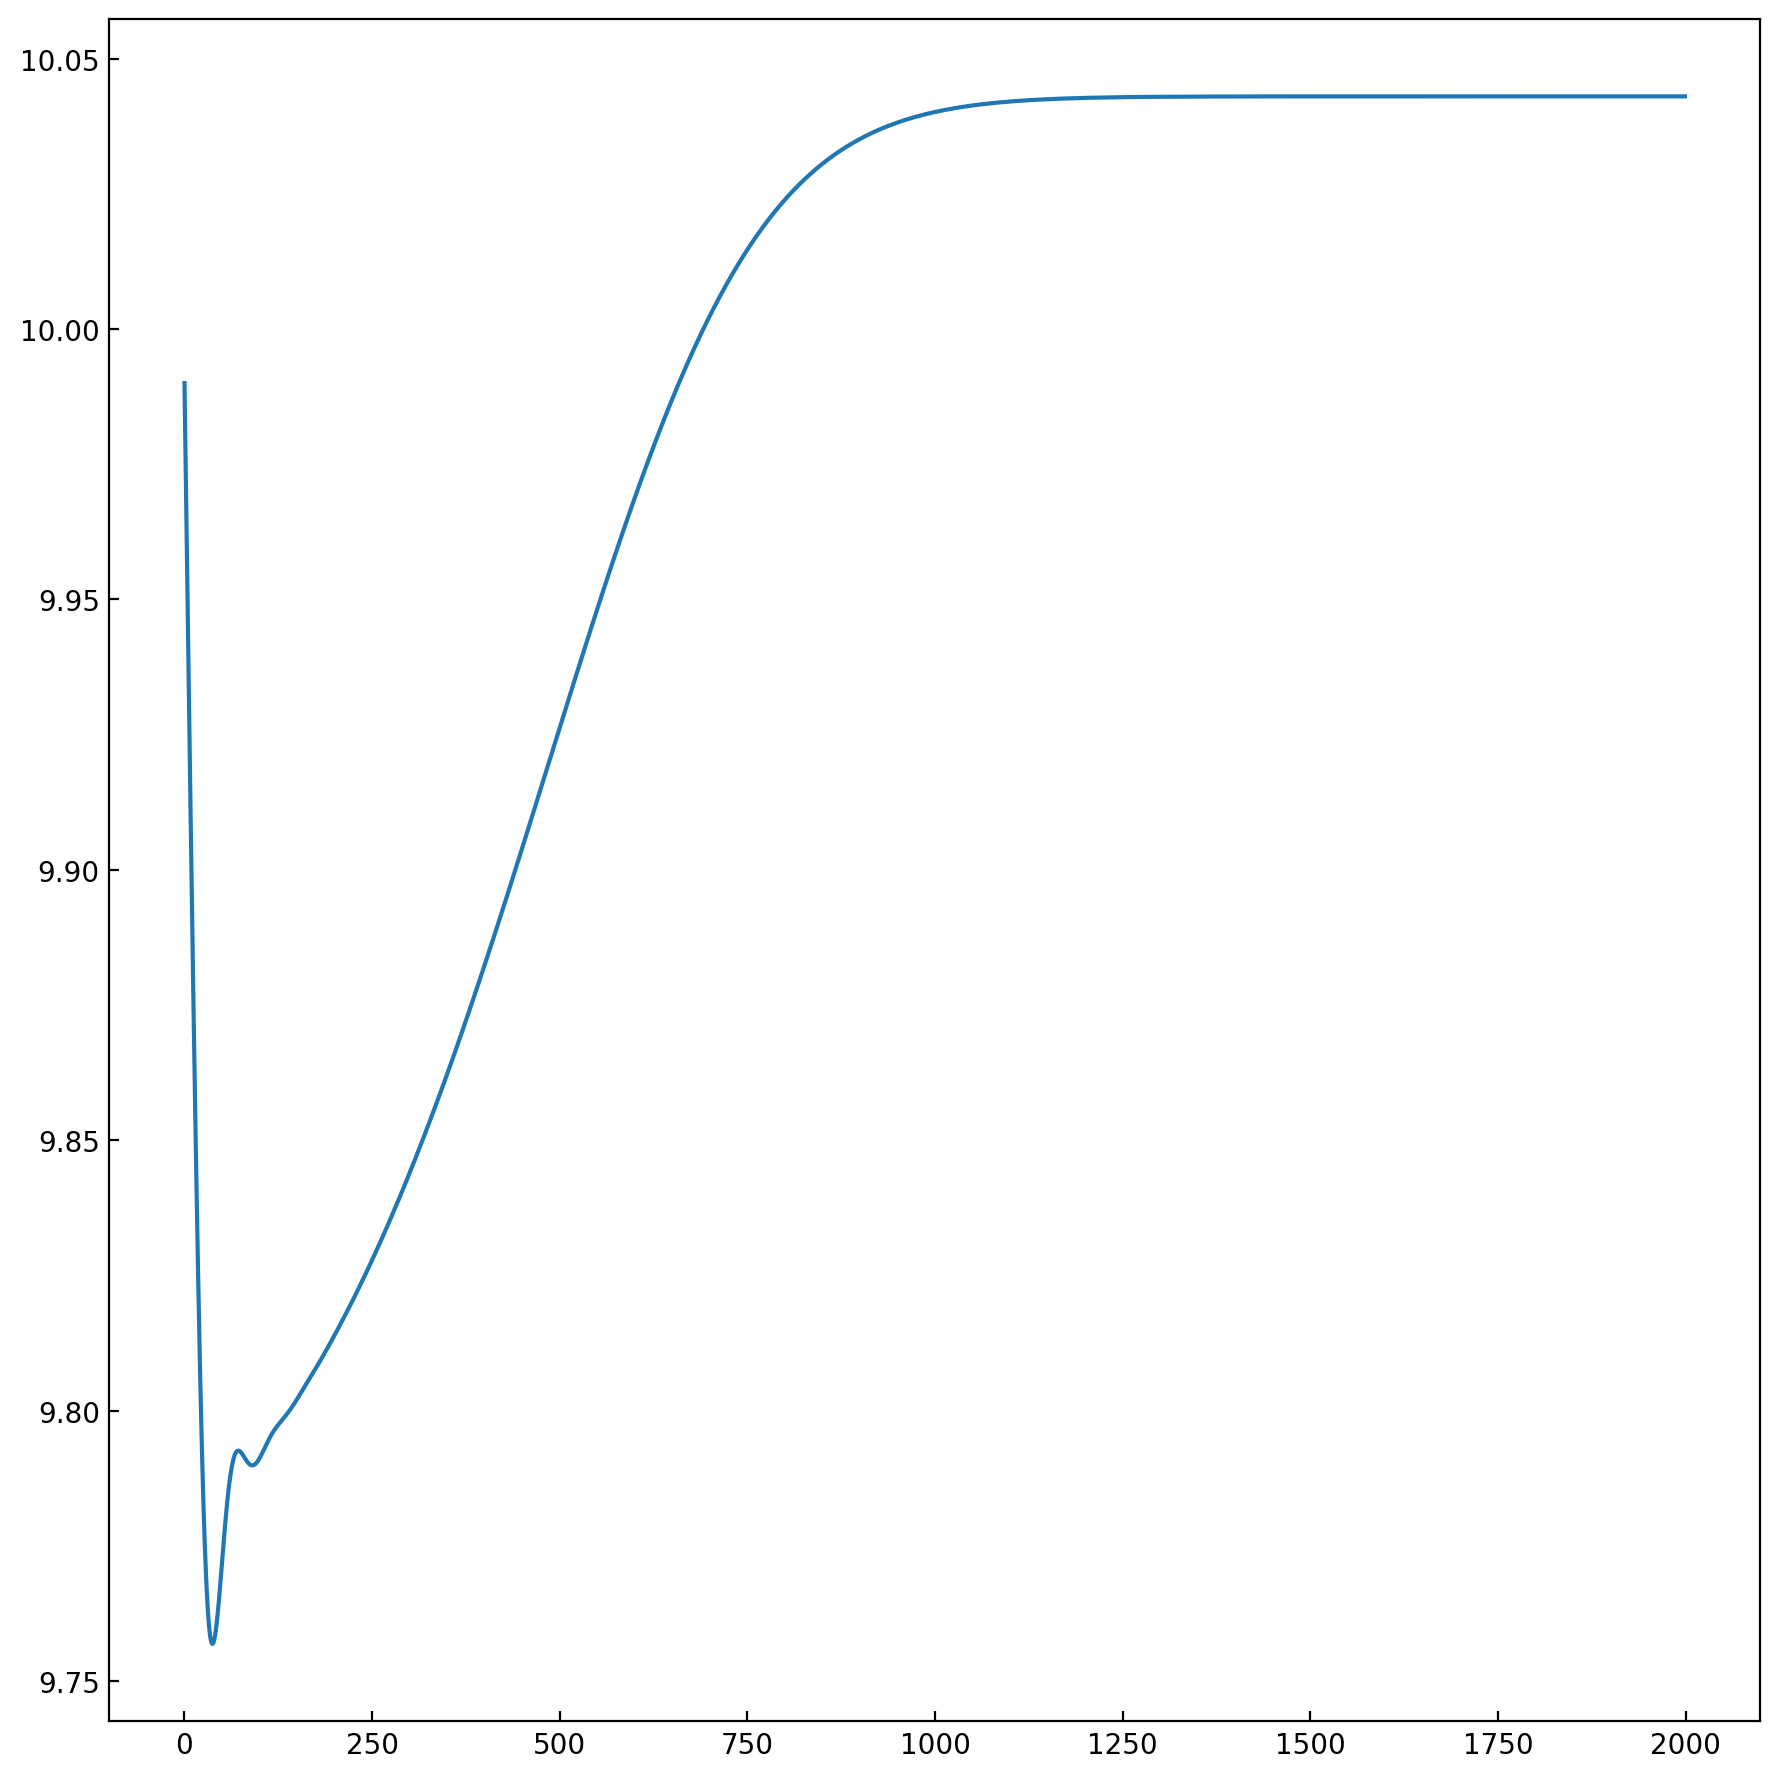

In [6]:
plt.plot(ms)

In [94]:
nb_grad2 = jax.jacrev(jax.scipy.stats.nbinom.logpmf, argnums=[2, 1])

print(nb_grad2(data[:1], true_r, true_r / (true_m + true_r)))
print(log_negative_binomial2_jac(data[:1], true_m, true_r))

(Array([9.], dtype=float32, weak_type=True), Array([-0.4640894], dtype=float32, weak_type=True))
[[ 9.         -0.46408848]]


In [79]:
true_r/true_p  -  data[0]/(1-true_p)

12.0

In [9]:
true_mean = nb_mean(true_r, true_p)
true_variance = nb_var(true_r, true_p)
print(true_mean, true_variance)
print(nb_mean(10., 10. / (10. + 10.)), nb_var(10., 10. / (10. + 10.)))

10.000000000000002 30.000000000000007
10.0 20.0


-941.4063245201828 -941.40625


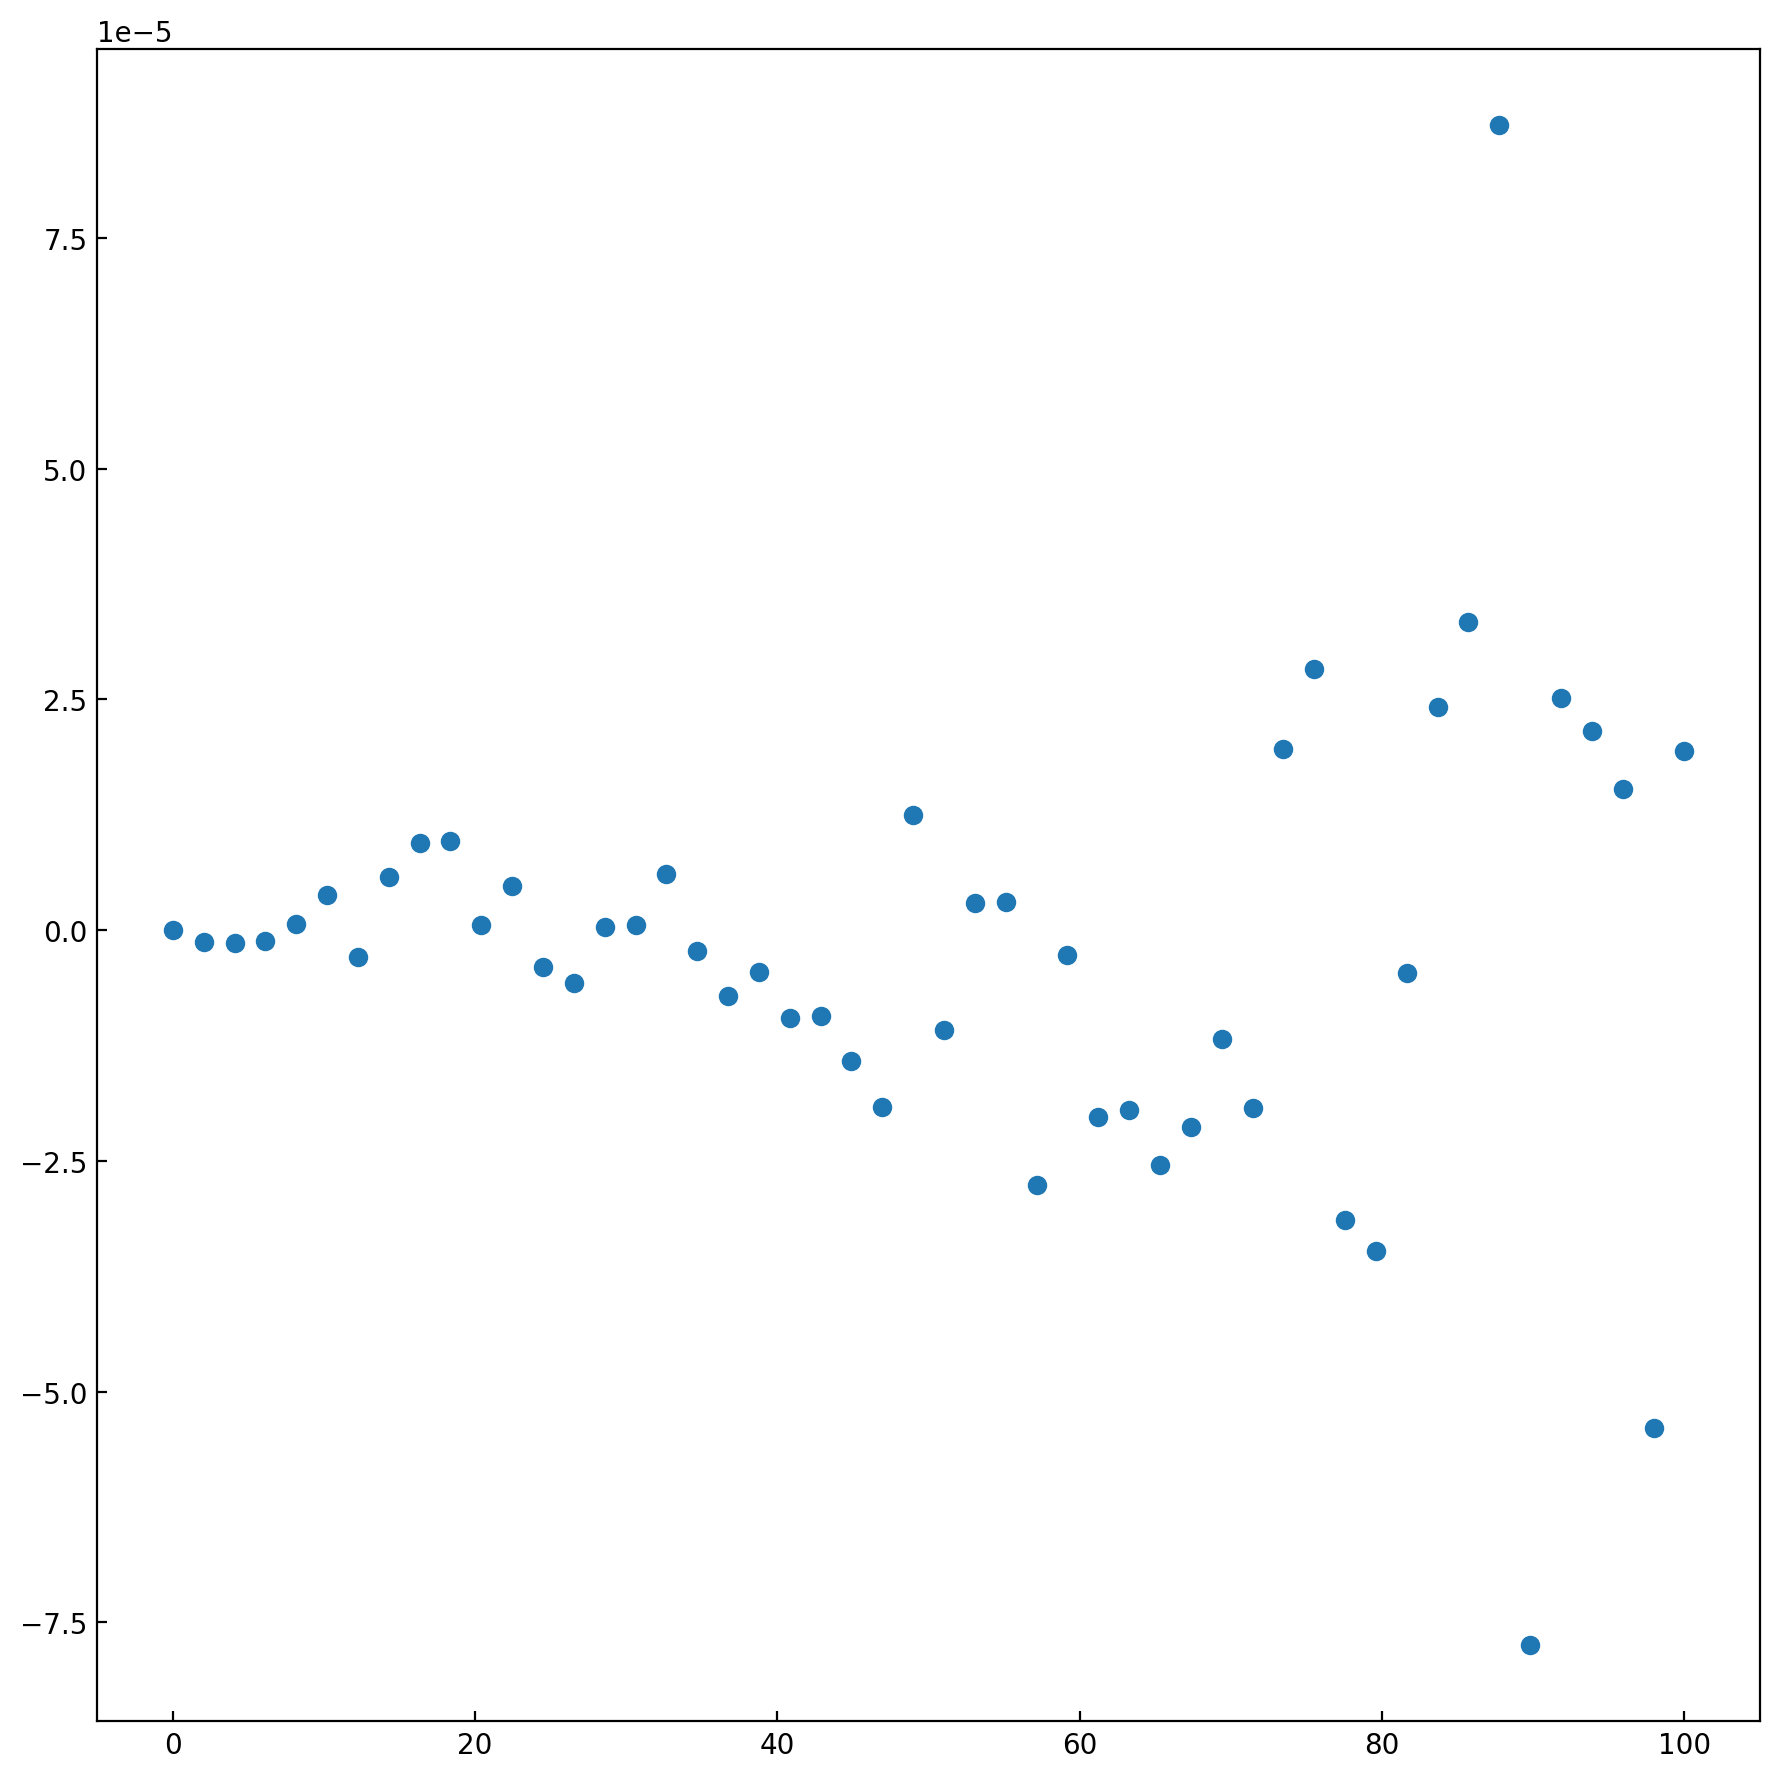

In [10]:
r = 10. + 1.4
m = 10. + 1.4
p = r / (r + m)
ks = np.linspace(0, 100, 50).astype(np.int32)
a = log_negative_binomial2(ks, m, r)
b = np.array([jax.scipy.stats.nbinom.logpmf(int(k), r, p) for k in np.linspace(0, 100, 50)])
# plt.plot(np.linspace(0, 100, 50), a, 'o')
plt.plot(np.linspace(0, 100, 50), a - b, 'o')

print(np.sum(a), np.sum(b))

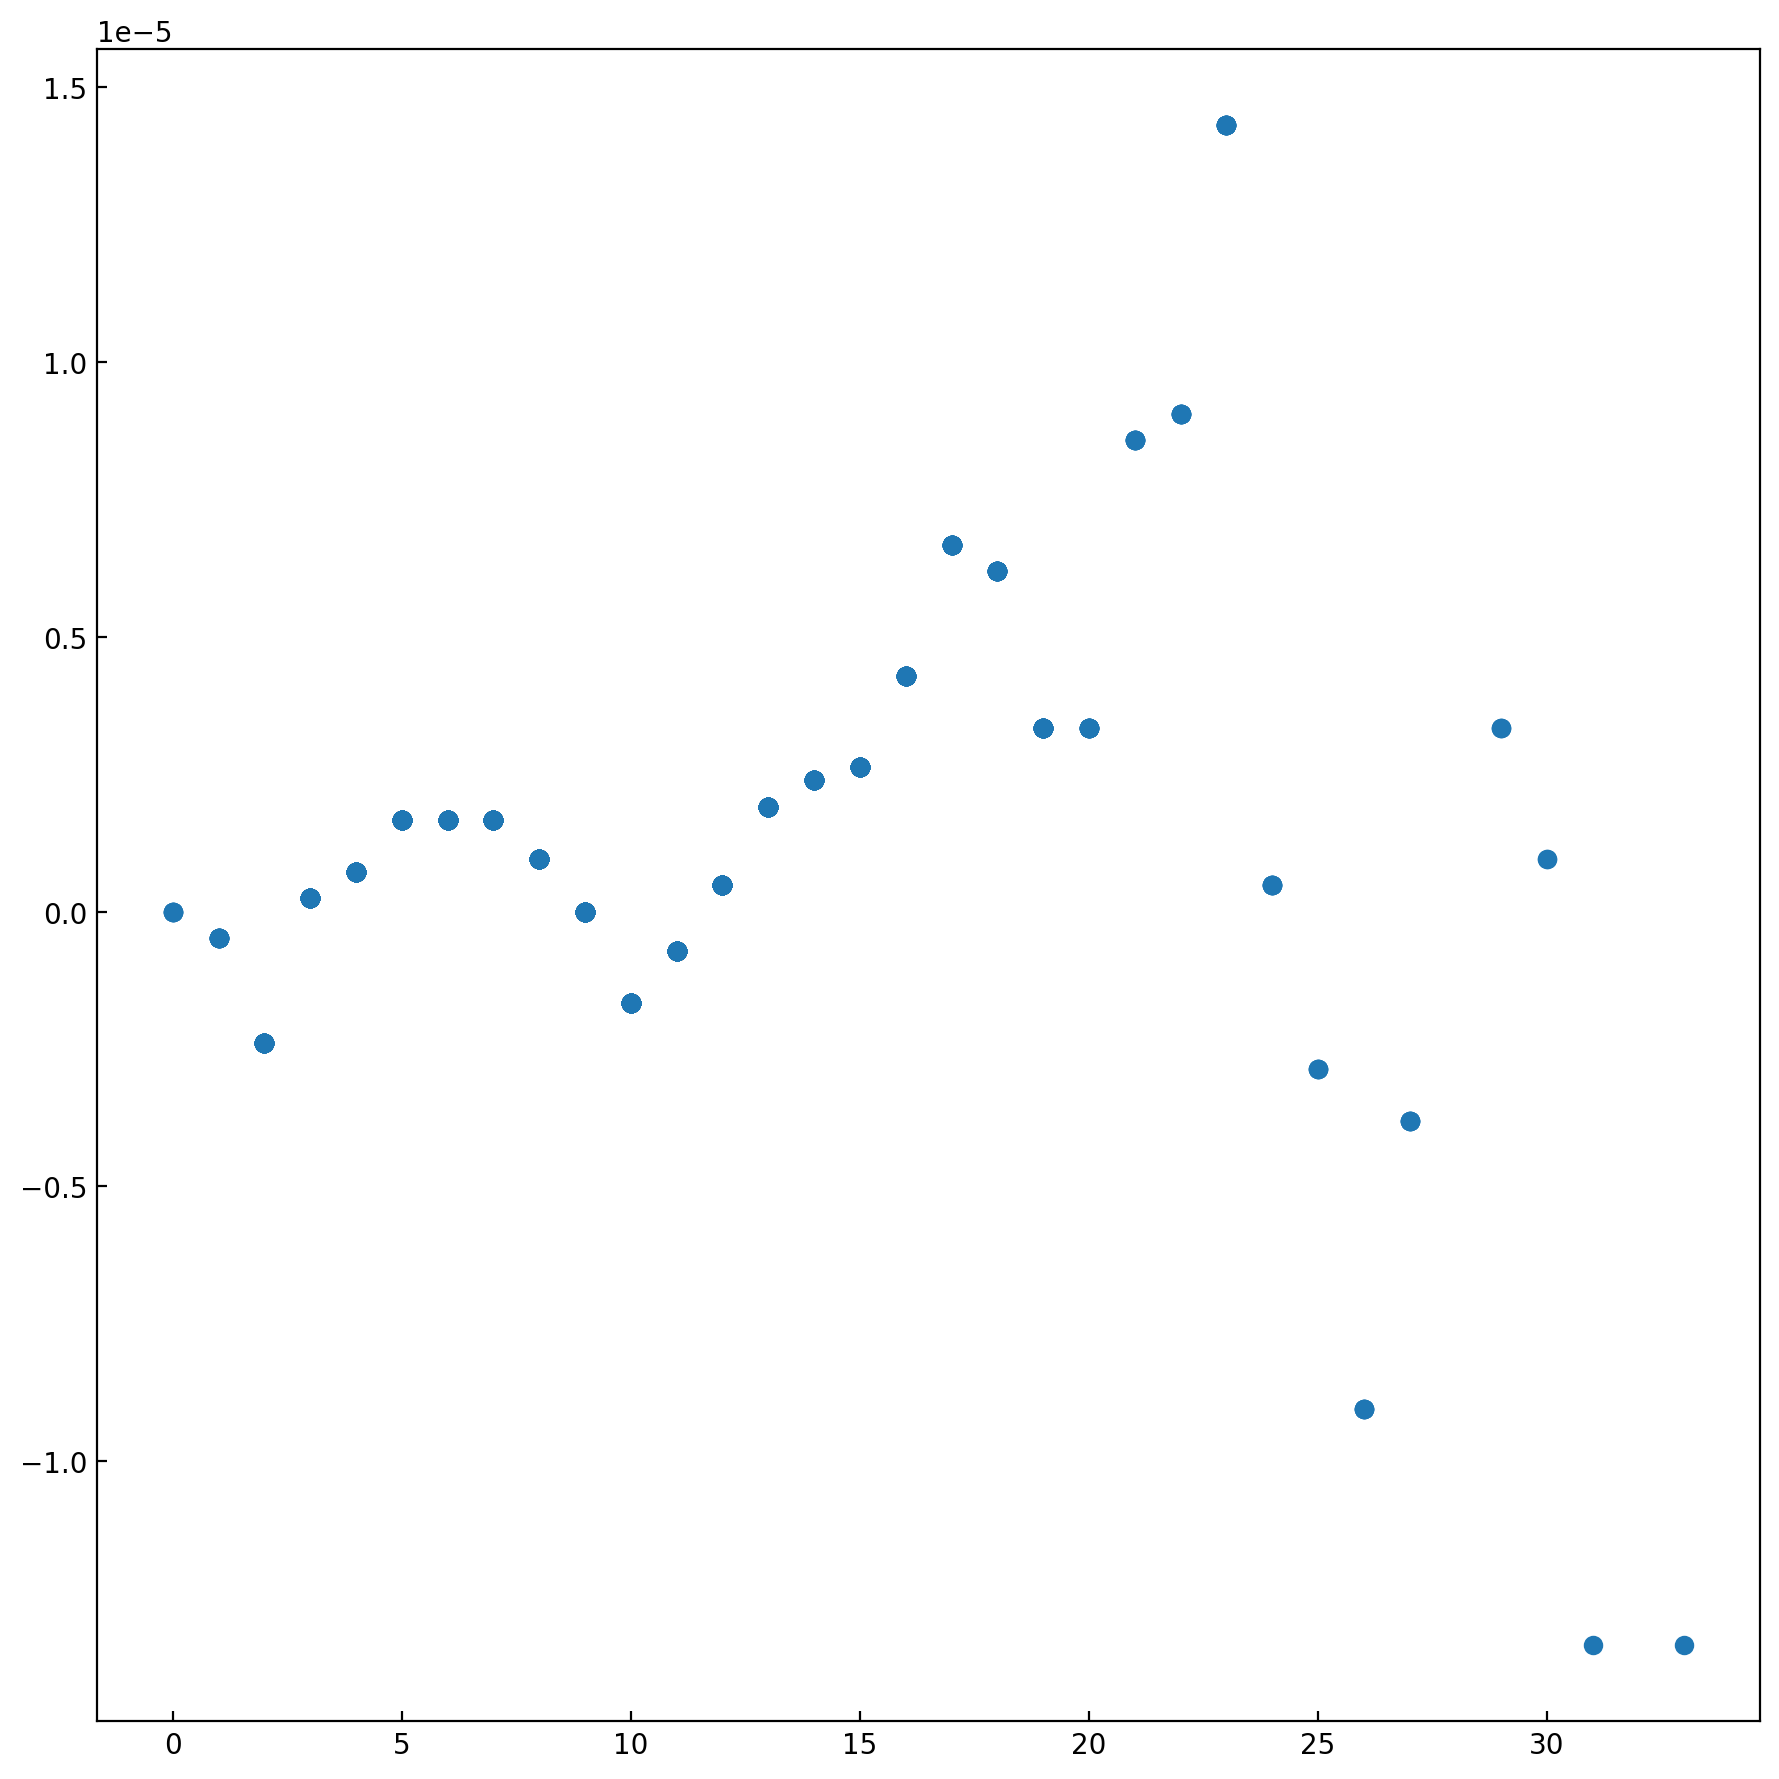

In [11]:
r = 10. - 1.1
m = 10.
p = r / (r + m)
a = np.array(log_negative_binomial2(data, m, r))
b = jax.scipy.stats.nbinom.logpmf(data, r, p)
# plt.plot(np.exp(a))
# plt.plot(np.exp(b))
plt.plot(data, a - b, 'o')
# print(np.sum(a), jnp.sum(b))

In [119]:
import jax
import jax.numpy as jnp
import numpy as np
from scipy.stats import nbinom
import optax
from tqdm import tqdm

from fast_negative_binomial import log_negative_binomial2, log_negative_binomial2_jac

def loss(params, data):
    m, r = params  # Direct parameters; assume r, m > 0
    log_pmf = log_negative_binomial2(data, m, r)
    return -jnp.sum(log_pmf)

def grad_loss(params, data):
    m, r = params

    loss_val = loss(params, data)

    dp_dm = -r / (m + r) ** 2

    jac = log_negative_binomial2_jac(data, m, r)
    jac[:, 0] *= dp_dm

    grads = jnp.mean(jac, axis = 0)

    return -grads, loss_val

def fit_negative_binomial(data, tol=1e-4, max_iters=1000, lr=1e-2):

    optimizer = optax.adam(lr)

    init_params = jnp.array([10., 10.])  # [m, r]
    opt_state = optimizer.init(init_params)
    params = init_params

    def step(params, opt_state, data):
        grads, loss_val = grad_loss(params, data)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_val

    # Optimization loop.
    for i in tqdm(range(max_iters)):
        params, opt_state, cur_loss = step(params, opt_state, data)
        if cur_loss < tol:
            print(f"Convergence reached at iteration {i} with loss {cur_loss:.6f}")
            break
    else:
        print(f"Maximum iterations reached with loss {cur_loss:.6f}")

    m, r = params
    return m, r, cur_loss

In [120]:
# Generate sample data from a negative binomial distribution.
true_r, true_m = 5.0, 10.0
true_p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, true_p, size=1000).astype(np.int32)

# for i in tqdm(range(100)):

fitted_m, fitted_r, final_loss = fit_negative_binomial(data, tol=1e-2, max_iters=1000, lr=1e-2)
print(f"Fitted parameters: m = {fitted_m:.3f}, r = {fitted_r:.3f}, final loss = {final_loss:.6f}")

100%|██████████| 1000/1000 [00:00<00:00, 1847.55it/s]

Maximum iterations reached with loss 3047.177246
Fitted parameters: m = 10.150, r = 5.259, final loss = 3047.177246


In [143]:
# Way faster with jax.jit -> would it be better just to solve this specifically in C++ using newton's method?

nb_grad2 = jax.jacrev(jax.scipy.stats.nbinom.logpmf, argnums=[2, 1])

@jax.jit
def loss(params, data):
    m, r = params  # Direct parameters; assume r, m > 0

    p = r / (r + m)
    log_pmf = jax.scipy.stats.nbinom.logpmf(data, r, p)
    
    return -jnp.sum(log_pmf)

@jax.jit
def grad_loss(params, data):
    m, r = params

    loss_val = loss(params, data)

    p = r / (r + m)

    dp_dm = -r / (m + r) ** 2

    jac = nb_grad2(data, r, p)

    jac = jnp.vstack(jac).T

    # jac[:, 0] *= dp_dm

    grads = jnp.mean(jac, axis = 0)

    return -grads, loss_val

@jax.jit
def fit_negative_binomial(data):#, tol=1e-4, max_iters=1000, lr=1e-2):

    tol=1e-4
    max_iters=1000
    lr=1e-2

    optimizer = optax.adam(lr)

    init_params = jnp.array([10., 10.])  # [m, r]
    opt_state = optimizer.init(init_params)
    params = init_params

    def step(params, opt_state, data):
        grads, loss_val = grad_loss(params, data)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_val

    # Optimization loop.
    for i in range(max_iters):
        params, opt_state, cur_loss = step(params, opt_state, data)
        # if cur_loss < tol:
            # print(f"Convergence reached at iteration {i} with loss {cur_loss:.6f}")
            # break
    # else:
        # print(f"Maximum iterations reached with loss {cur_loss:.6f}")

    m, r = params
    return m, r, cur_loss

In [2]:
# Generate sample data from a negative binomial distribution.
true_r, true_m = 3.5, 5.0
true_p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, true_p, size=10000).astype(np.int32)

data_a = np.vstack([nbinom.rvs(true_r, true_p, size=10000).astype(np.int32) for i in range(5000)]).T

# print(data_a.shape)

# for i in tqdm(range(100)):

#     # fitted_m, fitted_r, final_loss = fit_negative_binomial(data, tol=1e-2, max_iters=1000, lr=1e-2)
#     fitted_m, fitted_r, final_loss = fit_negative_binomial(data)
#     print(f"Fitted parameters: m = {fitted_m:.3f}, r = {fitted_r:.3f}, final loss = {final_loss:.6f}")

In [3]:
from fast_negative_binomial import optimise_all_genes, optimise

In [4]:
# %%timeit
ms_rs = optimise_all_genes(data_a.T)

In [5]:
ms_rs

[(5.000631547145104, 3.4024251800849905),
 (5.03176720245321, 3.433313353169474),
 (4.989547191543151, 3.2744618374858416),
 (4.969927733874486, 3.4714343000829238),
 (5.071044295996539, 3.570757198963103),
 (5.0157346213061205, 3.6093702064548174),
 (5.012688180663953, 3.5699803203758425),
 (4.968373644144811, 3.3822540500421963),
 (5.045763072836737, 3.5769089042157685),
 (4.994463864953967, 3.4932370174523606),
 (5.030187702050237, 3.420655401960196),
 (4.966731958773881, 3.4608387348937995),
 (5.005252967922487, 3.453134472980995),
 (5.011195479244591, 3.3830502935618667),
 (4.948695804584932, 3.395558068733512),
 (5.00483539286559, 3.4646042439161793),
 (4.9745071356032, 3.5581296791227883),
 (4.986680344846994, 3.470171073169841),
 (5.04627689664035, 3.5061049409385783),
 (5.046723812962374, 3.608295617653395),
 (5.021547226108603, 3.5500365685542428),
 (4.926971912979462, 3.377222918258859),
 (5.011274500894203, 3.5717197185377176),
 (4.9423993487422955, 3.4453095049763656),
 (5

In [6]:
optimise(data, 10., 10., 0.1, 1000)

(4.998487534550181, 3.6111672767963716)

<Axes: ylabel='Count'>

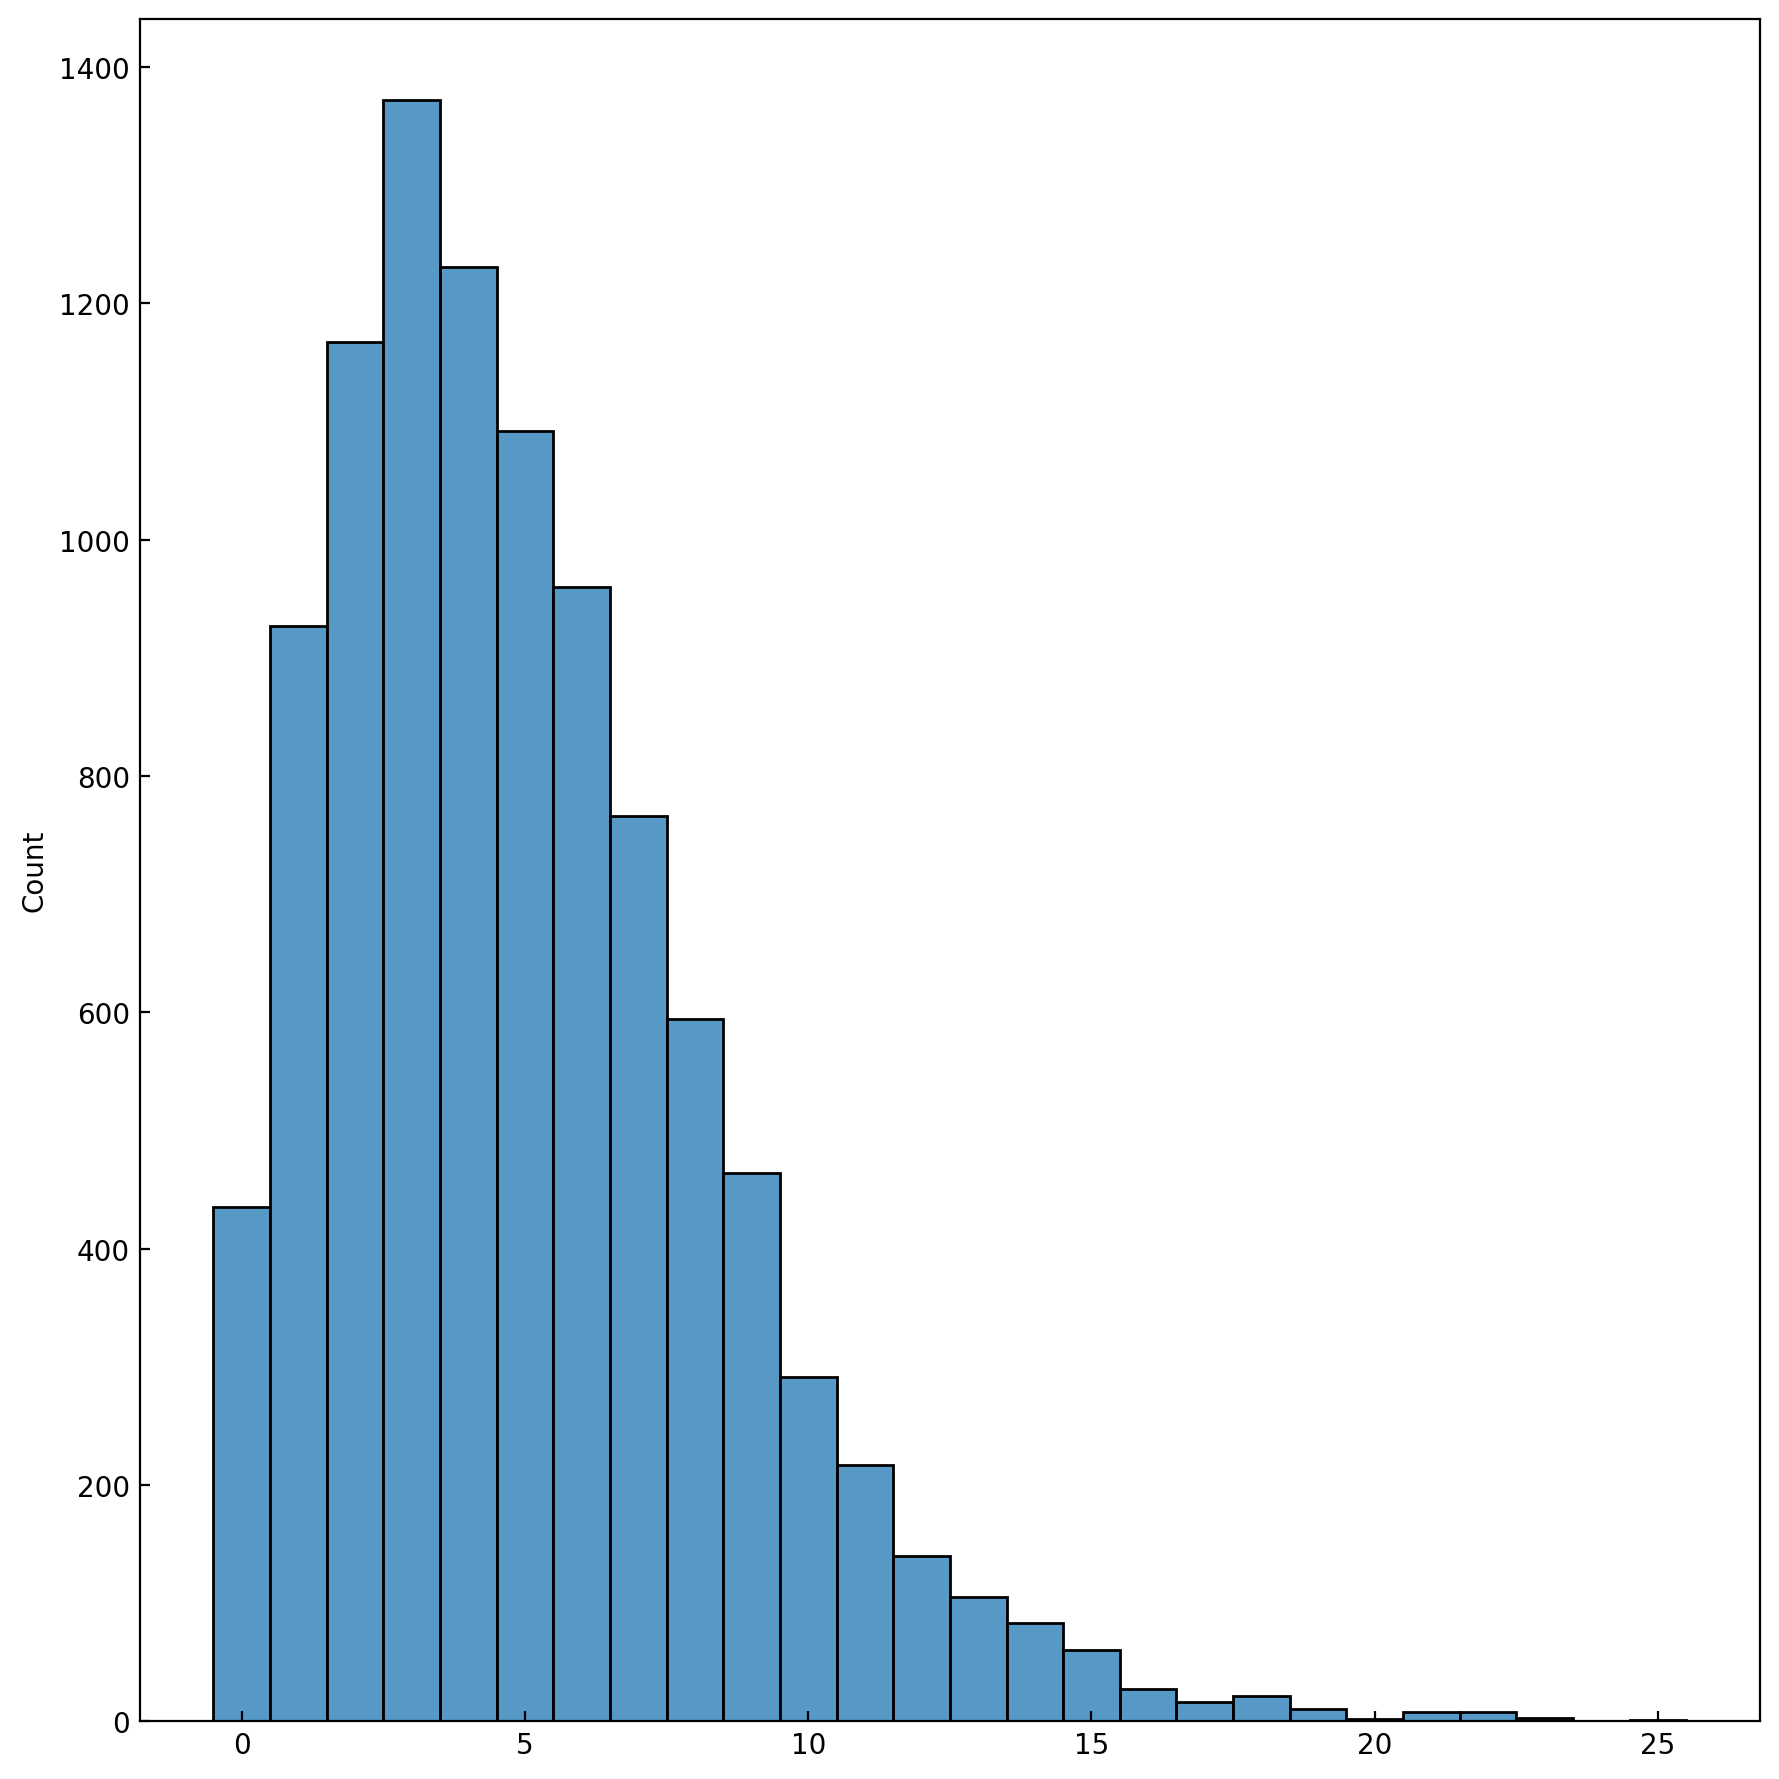

In [7]:
sns.histplot(data, bins = 50, discrete = True)

In [8]:
from fast_mutual_information import mi_negative_binomial

In [9]:
ms = [x[0] for x in ms_rs]
rs = [x[1] for x in ms_rs]

In [14]:
mi = mi_negative_binomial(data_a, ms, rs)

In [15]:
mi

array([[ 0.00000000e+00,  1.51649599e+05, -5.28527629e-05, ...,
        -5.21875486e-05, -5.22768565e-05, -5.14612661e-05],
       [ 0.00000000e+00,  0.00000000e+00, -5.24047560e-05, ...,
        -5.20443693e-05, -5.22596073e-05, -5.14978160e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -5.26784346e-05, -5.29256353e-05, -5.24461078e-05],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -5.25631879e-05, -5.16972039e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -5.14145461e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [30]:
sorted(mi.flatten())[-50:]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 147089.13059085558,
 151649.59936164253,
 152097.96878779892,
 152274.5920365385,
 152487.51172926737,
 152900.2494331362,
 153133.51324642872,
 153276.25769805786]

In [2]:
#  Define parameters
n_samples = 10000  # number of samples
n_dim = 100        # dimensionality

n_factors = 5  # Using a small number of factors to obtain a wider spread of correlations
B = np.random.randn(n_dim, n_factors)

# Replace the covariance construction with:
cov = np.dot(B, B.T)

# Step 3: Convert Σ to a correlation matrix R via normalization:
d = np.sqrt(np.diag(cov))
R = cov / np.outer(d, d)
np.fill_diagonal(R, 1.0)  # Ensure the diagonal elements are exactly 1

# Step 4: Draw samples from the multivariate normal distribution N(0, R)
mean = np.zeros(n_dim)
samples = np.random.multivariate_normal(mean, R, size=n_samples)

samples *= 10
samples += 50


In [3]:
means = np.zeros(samples.shape[1]) + 50
variances = np.ones(samples.shape[1]) * 100

In [4]:
print(np.mean(samples[:, 0]))
print(np.std(samples[:, 0])**2)

49.9781577012264
100.37768171525195


<Axes: >

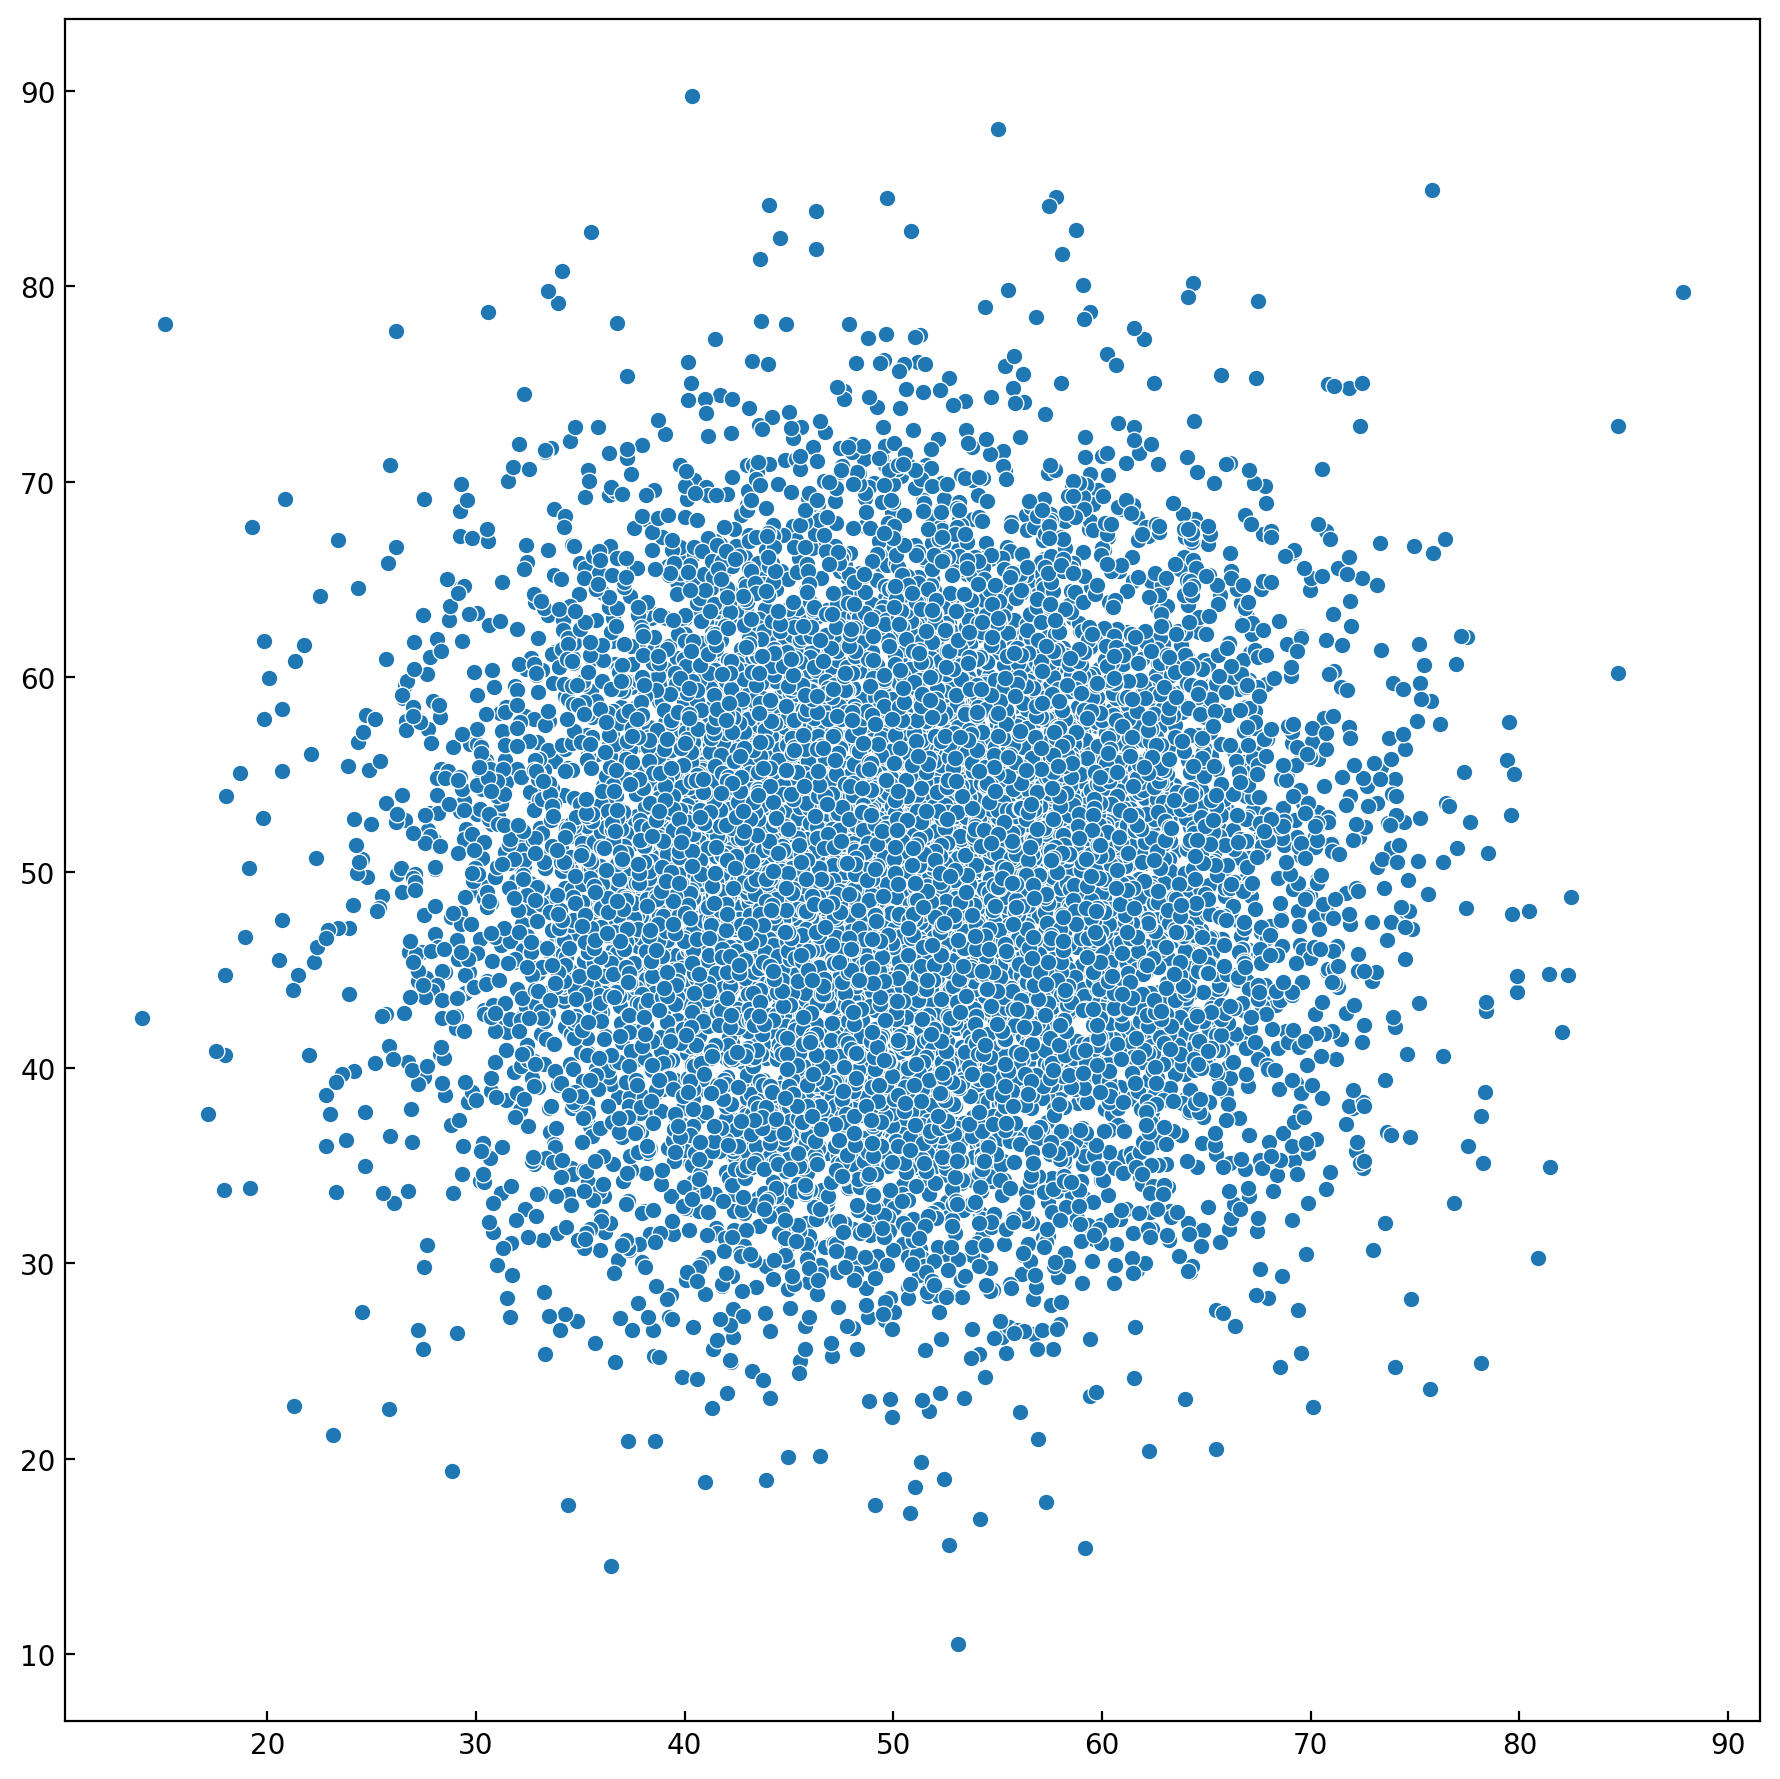

In [5]:
sns.scatterplot(x = samples[:, 0], y = samples[:, 1])

In [6]:
from fast_mutual_information import mi_normal

In [7]:
mi = mi_normal(samples.astype(np.int32), means, variances, min_pop = 10)
print(mi.shape)

(100, 100)


<Axes: ylabel='Count'>

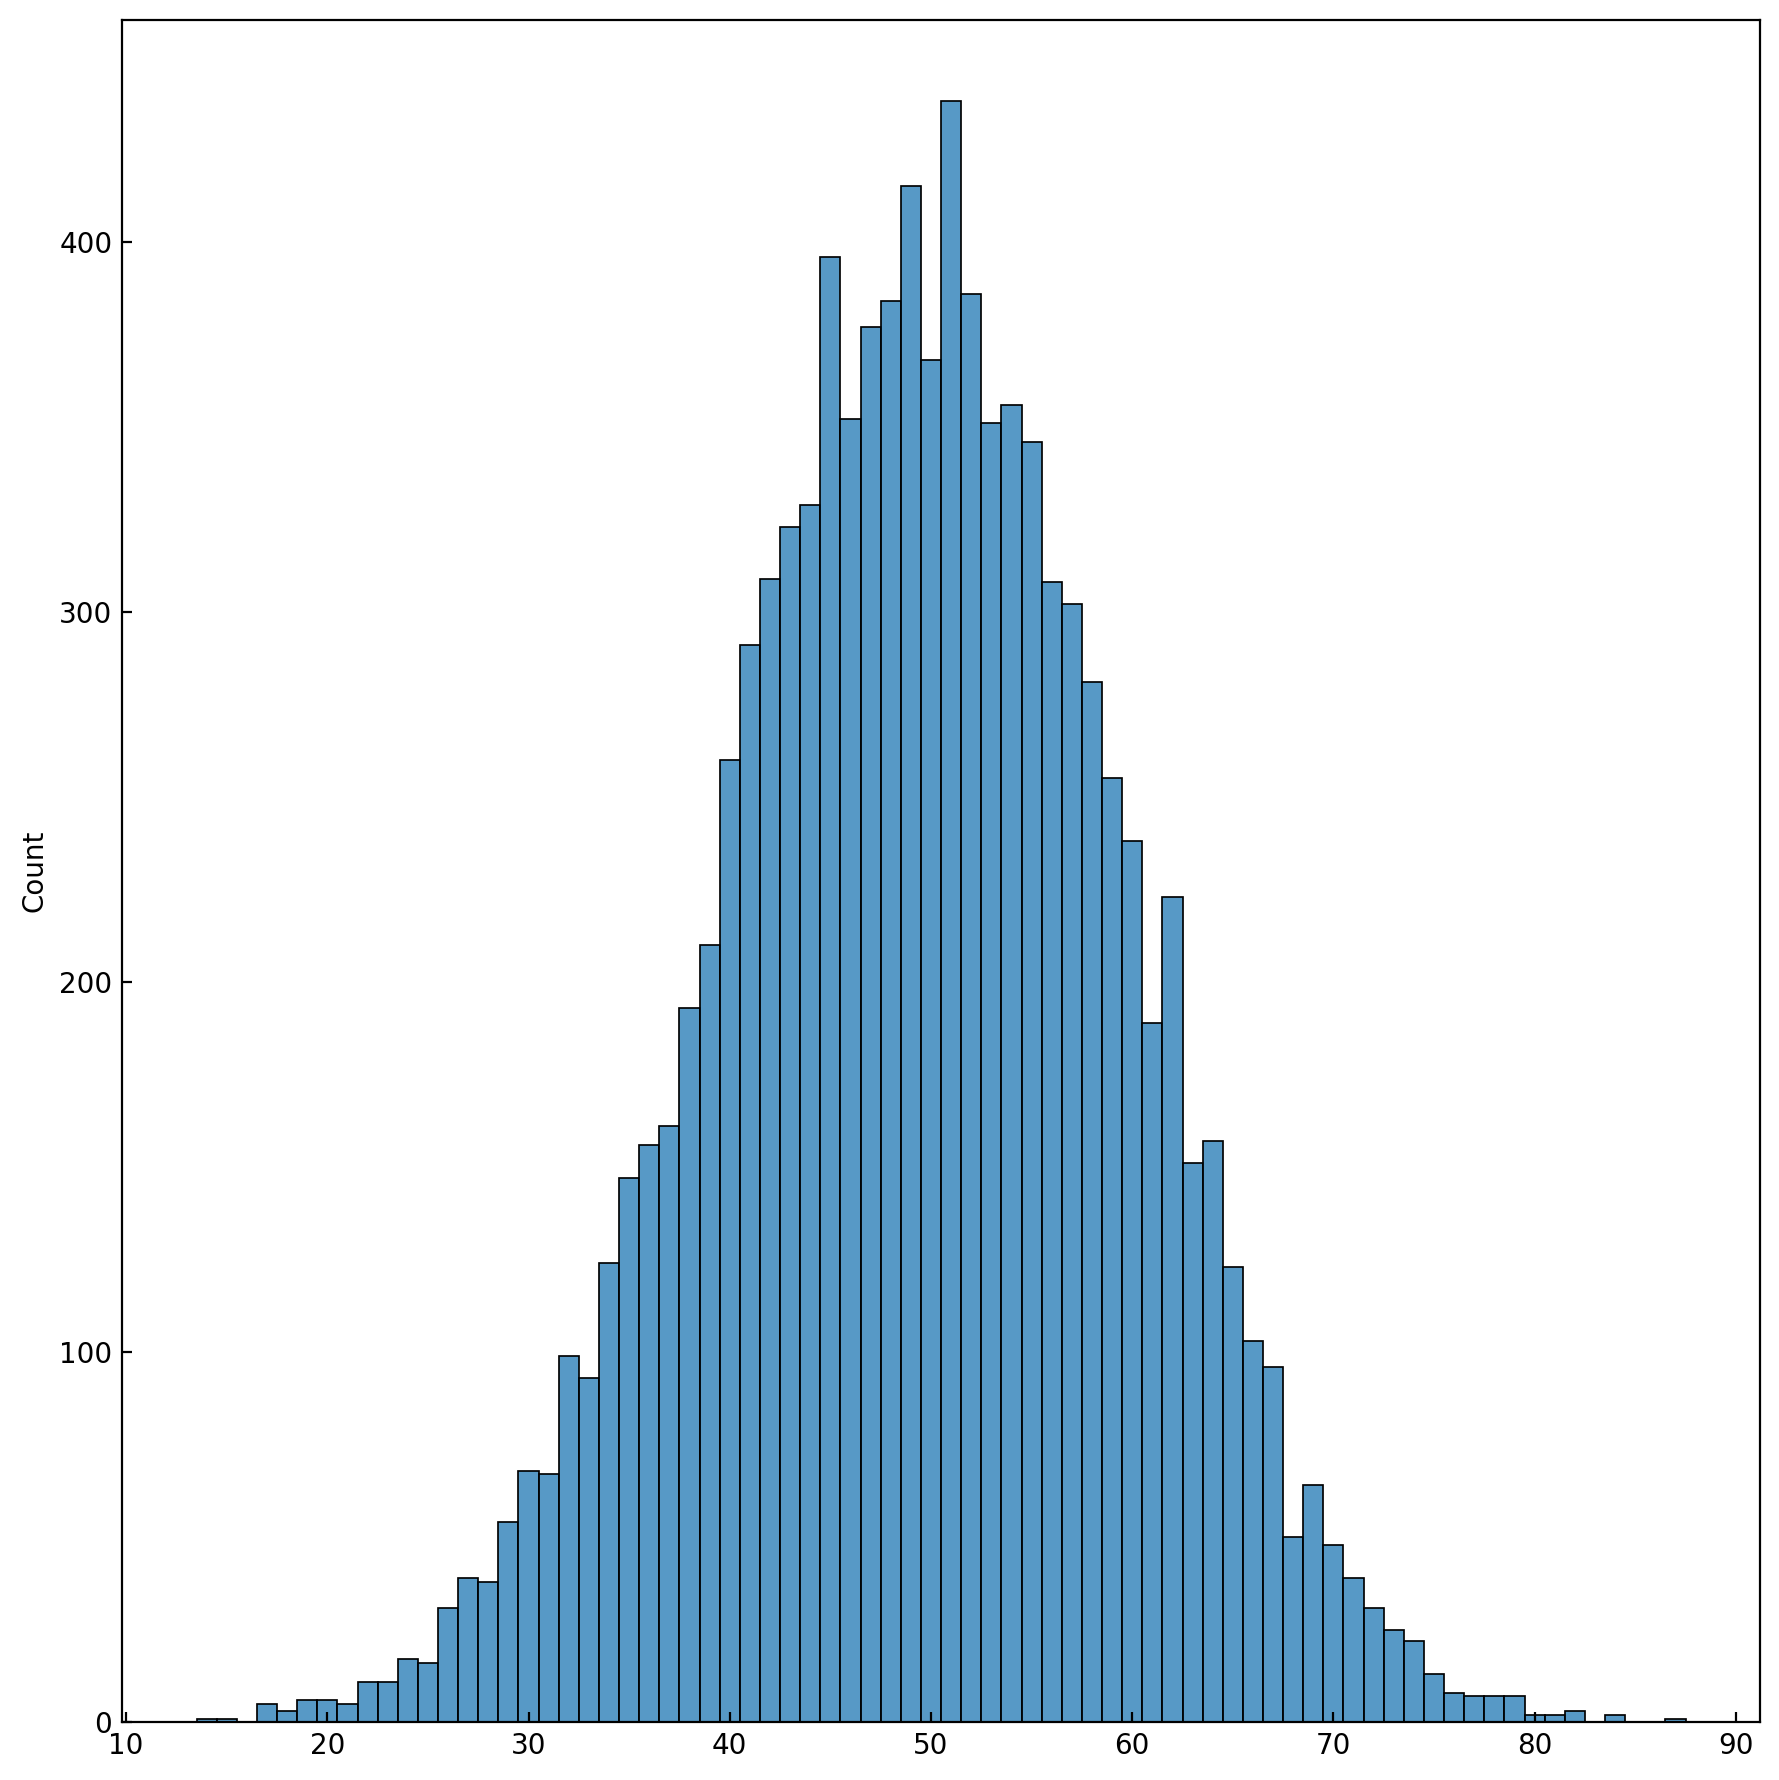

In [8]:
sns.histplot(samples[:, 0].astype(np.int32), discrete = True)

<Axes: >

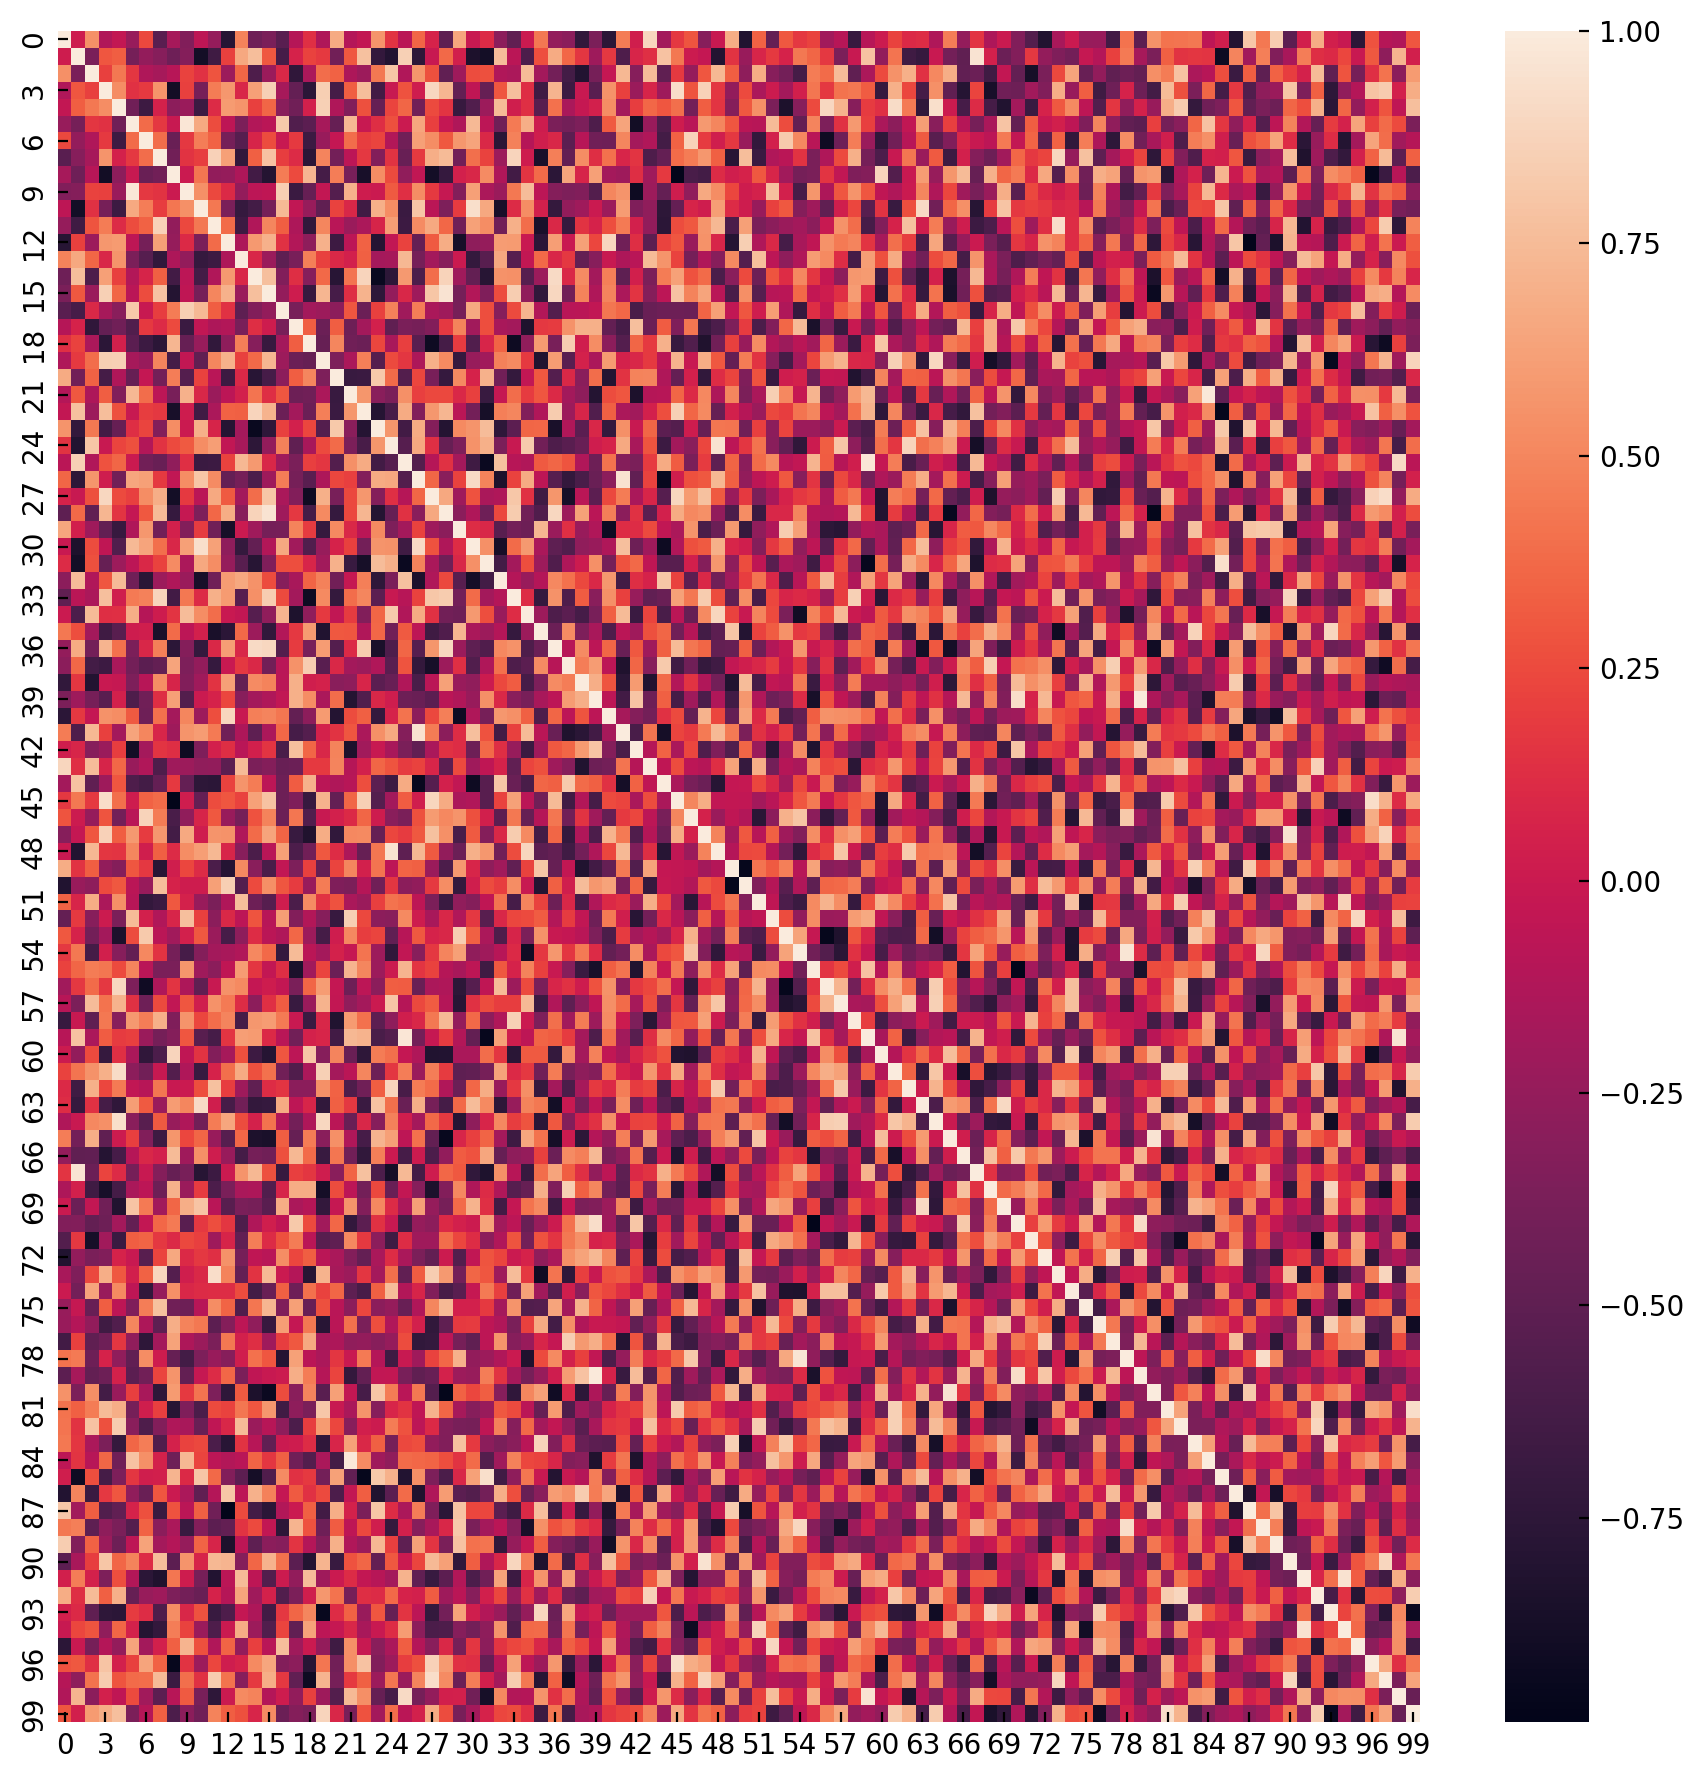

In [9]:
sns.heatmap(R)

In [12]:
# sns.heatmap(mi)
# sns.histplot(mi.flatten())
mi

array([[ 0.00000000e+000,  2.17279260e+004, -1.21961666e-004, ...,
        -1.22552556e-004, -1.22136062e-004, -1.22694860e-004],
       [ 2.13127269e-314,  5.87005666e+219, -1.22156454e-004, ...,
        -1.22412758e-004, -1.22301518e-004, -1.22264296e-004],
       [ 3.23790862e-319, -1.24253896e-272,  1.59552479e-032, ...,
        -1.22239625e-004, -1.22258449e-004, -1.22322177e-004],
       ...,
       [-1.90253504e-293, -1.72486629e-261,  3.64989699e-112, ...,
         8.13877879e-001, -1.22441673e-004, -1.22134902e-004],
       [-1.92946715e+015, -6.73118978e-289, -4.13207734e+062, ...,
        -1.36362214e-002,  1.81819001e-001, -1.21982979e-004],
       [ 4.85397288e+155, -3.14369087e-267,  8.95142381e-181, ...,
         1.94285561e-001,  1.08517820e-001, -7.64285579e-001]])